# **Observability models**

## Research questions
1. Do observability and identification of lions increase using drones compared to traditional
ground observation methods?
2. In which conditions lions are better observed by drones (habitat/light)?

### Hypothesis
1. **Observability and identification** (i.e., counts of individuals and identification of sex/age classes) **increases using drones** 
2. **Open or less dense vegetation areas increase observability** (animals are more visible),
   **early morning or late afternoon time of the day increases observability** (animals are less hided deep into the bushes and are more active)

In [21]:
# Packages

import os
import pymc as pm
import numpy as np
import arviz as az
import bambi as bmb
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from plotnine import (
    ggplot, aes, geom_point, geom_line, geom_ribbon, geom_abline, 
    labs, theme_bw, theme, element_text, element_text, labeller, guides, guide_legend, element_blank, scale_x_continuous, scale_y_continuous, scale_color_manual
)

from matplotlib.ticker import FuncFormatter, MaxNLocator
import pyperclip as pc

import seaborn as sns
import plotnine

from io import BytesIO
from PIL import Image
import plotnine as p9


import matplotlib.patches as mpatches




print("Imports succesful")

Imports succesful


In [22]:
# Upload dataset

file_path = 'ToleranceTest_MasterDoc.xlsx'

df = pd.read_excel(file_path, engine='openpyxl')

print(df.head())
print(df.columns.tolist())

  Test_ID       Date Species  Altitude      Time BF_Distance  \
0    AJ01 2024-11-07    Lion        60  10:33:00          38   
1    AJ02 2024-11-07    Lion       100  11:35:00          35   
2    AJ03 2024-11-07    Lion        40  11:50:00          35   
3    AJ04 2024-11-08    Lion       120  17:15:00          18   
4    AJ05 2024-11-08    Lion       100  17:47:00          14   

   BF_Distance_averaged BF_Agonistic BF_Aggressive/Flee BF_Fear  ...  \
0                    38            N                  N       N  ...   
1                    35            N                  N       N  ...   
2                    35            N                  N       N  ...   
3                    18          NaN                  N       N  ...   
4                    14          NaN                  N       N  ...   

  Drone_N_M Drone_N_c DroneVIDEO_N_Individual DroneVIDEO_N_F DroneVIDEO_N_M  \
0         2         3                       6              1              2   
1         2         3   

# **Data preparation**

In the following cells, data are manipulated in order to be ready to feed models following the research questions' objectives and expected hypothesis.

**CELL01**

- data are filtered by species to keep only data that refers to lion;
- a column called 'Pride_ID', which refers to the name of each pride tested, is created from the original 'Test_ID' column (each Test ID contains the initials of a pride name);
- 'Date' data are transformed into datetime format;
- a new column called 'Cluster_ID', which refers to the combined information of Pride ID and each trial day ID, is created;
- a new column called 'Time_Category', which categorize the time of the data collection into 'Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon', is created;
- a new column called 'Cluster_ID'; which represent each day of test x each pride, is created;
- The dataset is reshaped so that every observation coincides with a count type, which are:
  1. **ground close counts** ->'N_Individual_close', 'N_F_close', 'N_M_close', 'N_c_close';
  2. **ground far counts** ->'N_Individual_dronelaunch', 'N_F_dronelaunch', 'N_M_dronelaunch', 'N_c_dronelaunch';
  3. **drone in situ counts** ->'Drone_N_Individual', 'Drone_N_F', 'Drone_N_M', 'Drone_N_c';
  4. **drone recording counts** - >'DroneVIDEO_N_Individual', 'DroneVIDEO_N_F', 'DroneVIDEO_N_M', 'DroneVIDEO_N_c'.
 
Note that **N_Individual** stays for *Total Number of Individuals*, **N_F** for *Number of Adult Females*, **N_M** for *Number of Adult Males* and **N_c** for *Number of Cubs*

Therefore, a new categorical variable 'counts_type' is created together with the column 'total_counts', which values are the numeric counts


In [23]:
# CELL01

# data preparation 

data = df[['Test_ID', 'Date', 'Species', 'Time', 'BF_Distance_averaged',
           'N_Individual_close', 'N_F_close', 'N_M_close', 'N_c_close',
           'N_Individual_dronelaunch', 'N_F_dronelaunch', 'N_M_dronelaunch', 'N_c_dronelaunch',
           'Drone_N_Individual', 'Drone_N_F', 'Drone_N_M', 'Drone_N_c',
           'DroneVIDEO_N_Individual', 'DroneVIDEO_N_F', 'DroneVIDEO_N_M', 'DroneVIDEO_N_c',
           'Kill', 'vegetation', 'prides']]

data = data[data['Species'] == 'Lion']


data['Pride_ID'] = data['Test_ID'].str[:2]

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Convert 'Time' to datetime
data['Time'] = pd.to_datetime(data['Time'], format='%H:%M:%S').dt.time

# ADD: Cluster_ID as Pride_ID + 'x' + DDMM
data['Cluster_ID'] = data['Pride_ID'].astype(str) + 'x' + data['Date'].dt.strftime('%d%m')

# Function to categorize time
def categorize_time(time):
    if time >= pd.to_datetime('07:00').time() and time < pd.to_datetime('09:00').time():
        return 'Early morning'
    if time >= pd.to_datetime('09:00').time() and time < pd.to_datetime('11:00').time():
        return 'Mid morning'
    elif time >= pd.to_datetime('11:00').time() and time < pd.to_datetime('13:00').time():
        return 'Late morning'
    elif time >= pd.to_datetime('15:00').time() and time < pd.to_datetime('17:00').time():
        return 'Mid afternoon'
    elif time >= pd.to_datetime('17:00').time() and time < pd.to_datetime('19:00').time():
        return 'Late afternoon'
    else:
        return 'Other'

data['Time_Category'] = data['Time'].apply(categorize_time)

category_order = pd.CategoricalDtype(
    categories=['Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon'],
    ordered=True
)

data['Time_Category'] = data['Time_Category'].astype(category_order)

# Columns to be transformed
count_columns = ['N_Individual_close', 'N_F_close', 'N_M_close', 'N_c_close', 
                 'N_Individual_dronelaunch', 'N_F_dronelaunch', 'N_M_dronelaunch', 'N_c_dronelaunch', 
                 'Drone_N_Individual', 'Drone_N_F', 'Drone_N_M', 'Drone_N_c', 
                 'DroneVIDEO_N_Individual', 'DroneVIDEO_N_F', 'DroneVIDEO_N_M', 'DroneVIDEO_N_c']

# Melt the DataFrame to create 'counts_type' and 'total_count'
melted_df = data.melt(id_vars=['Test_ID', 'Date', 'Species', 'Time',
                               'BF_Distance_averaged', 'Kill', 'vegetation', 'prides', 'Time_Category', 'Cluster_ID'],
                      value_vars=count_columns,
                      var_name='counts_type',
                      value_name='total_count')

# Display the transformed DataFrame
data = melted_df
print(data)

     Test_ID       Date Species      Time  BF_Distance_averaged Kill  \
0       AJ01 2024-11-07    Lion  10:33:00                    38    N   
1       AJ02 2024-11-07    Lion  11:35:00                    35    N   
2       AJ03 2024-11-07    Lion  11:50:00                    35    N   
3       AJ04 2024-11-08    Lion  17:15:00                    18    N   
4       AJ05 2024-11-08    Lion  17:47:00                    14    N   
...      ...        ...     ...       ...                   ...  ...   
1099    WA09 2024-11-23    Lion  17:13:00                    36    Y   
1100    WA10 2024-11-25    Lion  09:11:00                    48    N   
1101    WA11 2024-11-25    Lion  09:31:00                   167    N   
1102    WA12 2024-11-25    Lion  10:05:00                    40    N   
1103    WA13 2024-11-25    Lion  10:35:00                    50    N   

                vegetation   prides   Time_Category Cluster_ID  \
0     Acacia drepanolobium    Ajali     Mid morning    AJx0711   
1  

**CELL02**

Here we create the variables 'Time_Angle', 'Time_Sin' and 'Time_Cos' extracted from the Time_category predictor of the previous cell. This is because eventually we want to see how time as a circular predictor (instead of a categorical) fits our models.

In [24]:
# CELL02
# Convert datetime.time to numeric hours
data['Time_Hours'] = data['Time'].apply(lambda t: t.hour + t.minute/60 + t.second/3600)

# Convert hours to angles (0-24 hours maps to 0-360 degrees)
data['Time_Angle'] = (data['Time_Hours'] / 24) * 360

# Convert angles to radians
data['Time_Radians'] = np.deg2rad(data['Time_Angle'])

# Compute sine and cosine
data['Time_Sin'] = np.sin(data['Time_Radians'])
data['Time_Cos'] = np.cos(data['Time_Radians'])

# Display results
print(data[['Time', 'Time_Hours', 'Time_Angle', 'Time_Sin', 'Time_Cos']])

          Time  Time_Hours  Time_Angle  Time_Sin  Time_Cos
0     10:33:00   10.550000      158.25  0.370557 -0.928810
1     11:35:00   11.583333      173.75  0.108867 -0.994056
2     11:50:00   11.833333      177.50  0.043619 -0.999048
3     17:15:00   17.250000      258.75 -0.980785 -0.195090
4     17:47:00   17.783333      266.75 -0.998392 -0.056693
...        ...         ...         ...       ...       ...
1099  17:13:00   17.216667      258.25 -0.979045 -0.203642
1100  09:11:00    9.183333      137.75  0.672367 -0.740218
1101  09:31:00    9.516667      142.75  0.605294 -0.796002
1102  10:05:00   10.083333      151.25  0.480989 -0.876727
1103  10:35:00   10.583333      158.75  0.362438 -0.932008

[1104 rows x 5 columns]


# **Exploratory analysis - plotting of input/output variables**

In this section, we will plot the variables shaped in the previous section ('Data preparation - CELL01'). In particular, we will plot the numerical *total_count* against the categorical predictor *counts_type*, also filtering for sex/age types of counts, the categorical predictor *vegetation* and the predictor *time_category*. This will help us to overview the distribution of the output and how it is affected by the input variables:

1. Different types of counts
2. Vegetation types
3. Time of the day

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/1523002054.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/1523002054.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


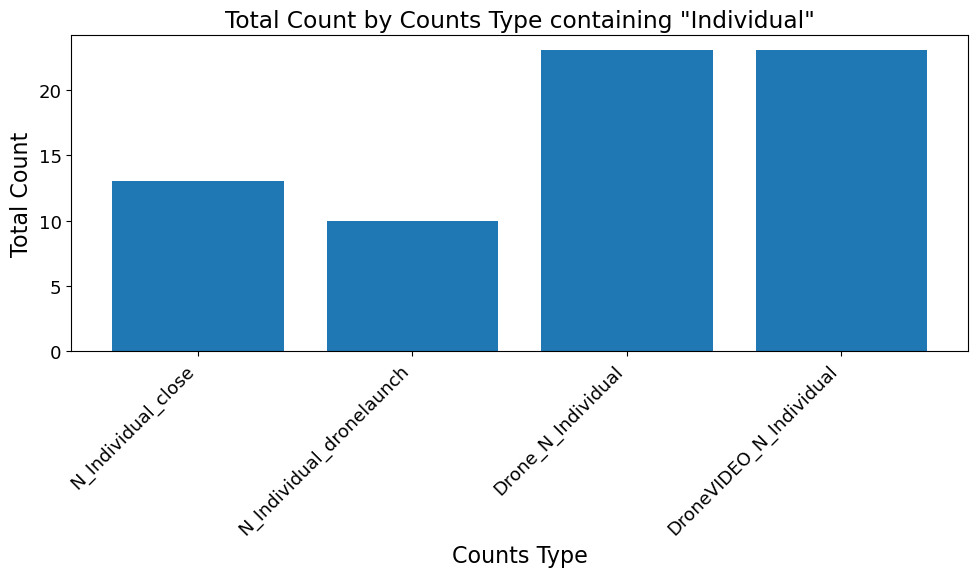

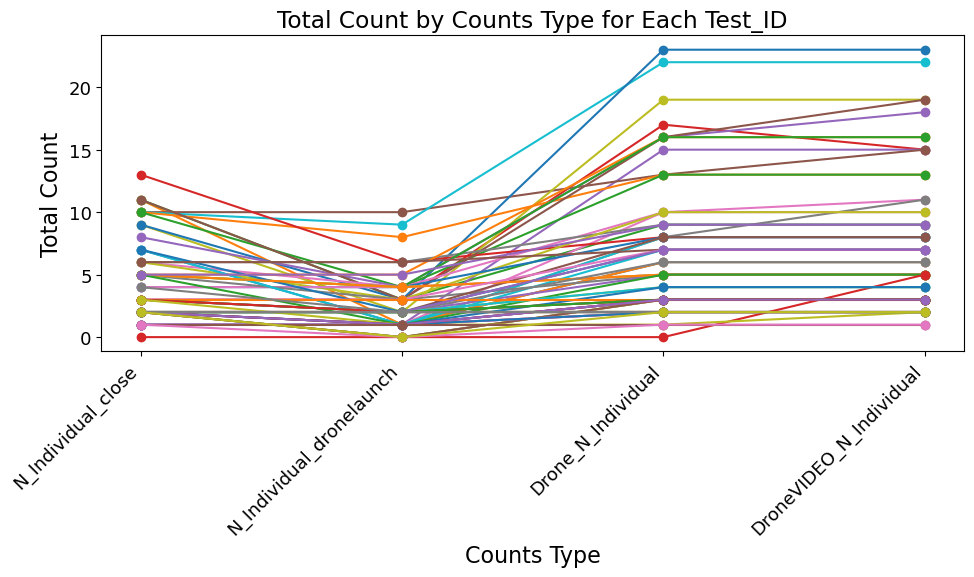

In [25]:
# 1.1 COUNTS TYPE: 
# TOTAL NUMBER OF INDIVIDUALS VS COUNTS TYPE

# Filter the DataFrame to keep only rows where 'counts_type' contains 'Individuals'
filtered_data = data[data['counts_type'].str.contains('Individual', case=False, na=False)]
filtered_data['counts_type'] = filtered_data['counts_type'].astype('category')  # Ensure categorical
filtered_data['total_count'] = filtered_data['total_count'].astype(int)

# Plot the filtered categorical column against the numerical column
plt.figure(figsize=(10, 6))
plt.bar(filtered_data['counts_type'], filtered_data['total_count'])
plt.xlabel('Counts Type')
plt.ylabel('Total Count')
plt.title('Total Count by Counts Type containing "Individual"')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Ensure 'counts_type' is categorical
data['counts_type'] = data['counts_type'].astype('category')
filtered_data = data[data['counts_type'].str.contains('Individual', case=False, na=False)]

# Group the data by 'Test_ID'
grouped_data = filtered_data.groupby('Test_ID')

# Plot each 'Test_ID' group with a different color
plt.figure(figsize=(10, 6))
for name, group in grouped_data:
    plt.plot(group['counts_type'], group['total_count'], marker='o', linestyle='-', label=f'Test_ID {name}')

plt.xlabel('Counts Type')
plt.ylabel('Total Count')
plt.title('Total Count by Counts Type for Each Test_ID')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/290714891.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/290714891.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


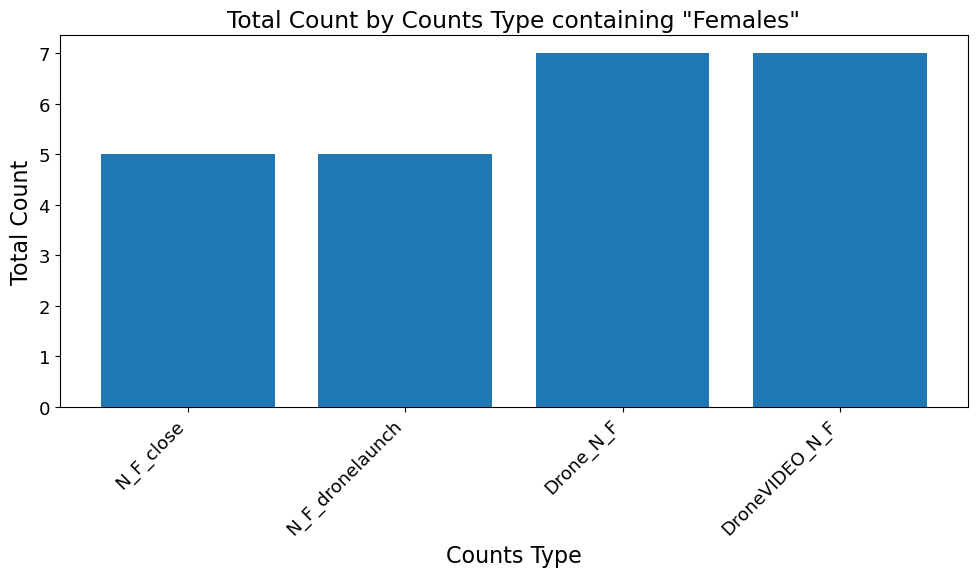

In [26]:
# 1.2  COUNTS TYPE: 
# TOTAL NUMBER OF FEMALES VS COUNTS TYPE

# Filter the DataFrame to keep only rows where 'counts_type' contains 'Individuals'
filtered_data = data[data['counts_type'].str.contains('F', case=False, na=False)]
filtered_data['counts_type'] = filtered_data['counts_type'].astype('category')  # Ensure categorical
filtered_data['total_count'] = filtered_data['total_count'].astype(int)

# Plot the filtered categorical column against the numerical column
plt.figure(figsize=(10, 6))
plt.bar(filtered_data['counts_type'], filtered_data['total_count'])
plt.xlabel('Counts Type')
plt.ylabel('Total Count')
plt.title('Total Count by Counts Type containing "Females"')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/3929695758.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/3929695758.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


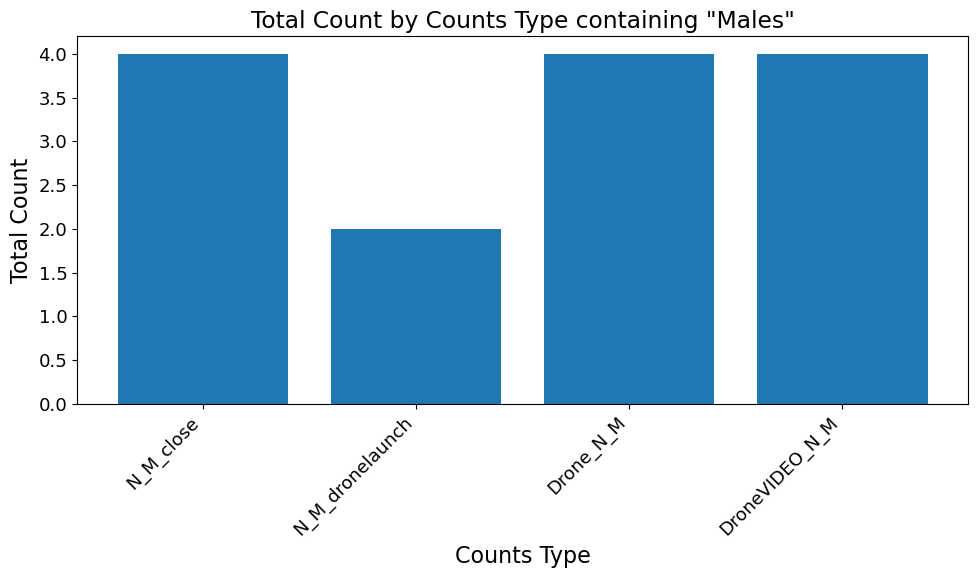

In [27]:
# 1.3 COUNTS TYPE: 
# TOTAL NUMBER OF MALES VS COUNTS TYPE

# Filter the DataFrame to keep only rows where 'counts_type' contains 'Individuals'
filtered_data = data[data['counts_type'].str.contains('M', case=False, na=False)]
filtered_data['counts_type'] = filtered_data['counts_type'].astype('category')  # Ensure categorical
filtered_data['total_count'] = filtered_data['total_count'].astype(int)

# Plot the filtered categorical column against the numerical column
plt.figure(figsize=(10, 6))
plt.bar(filtered_data['counts_type'], filtered_data['total_count'])
plt.xlabel('Counts Type')
plt.ylabel('Total Count')
plt.title('Total Count by Counts Type containing "Males"')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/1014794915.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/1014794915.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


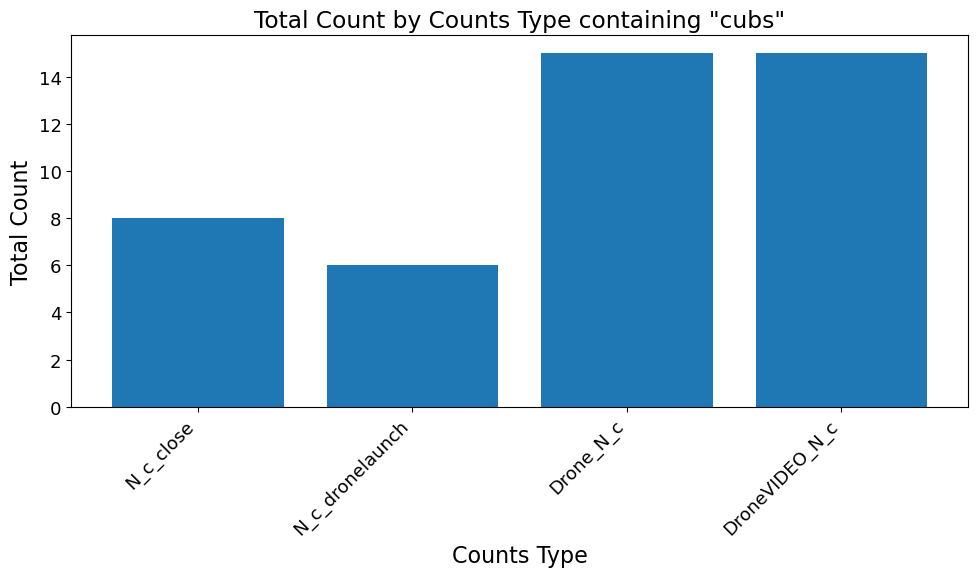

In [28]:
# 1.4 COUNTS TYPE: 
# TOTAL NUMBER OF CUBS VS COUNTS TYPE

# Filter the DataFrame to keep only rows where 'counts_type' contains 'Individuals'
filtered_data = data[data['counts_type'].str.contains('N_c', case=False, na=False)]
filtered_data['counts_type'] = filtered_data['counts_type'].astype('category')  # Ensure categorical
filtered_data['total_count'] = filtered_data['total_count'].astype(int)

# Plot the filtered categorical column against the numerical column
plt.figure(figsize=(10, 6))
plt.bar(filtered_data['counts_type'], filtered_data['total_count'])
plt.xlabel('Counts Type')
plt.ylabel('Total Count')
plt.title('Total Count by Counts Type containing "cubs"')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/284137577.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


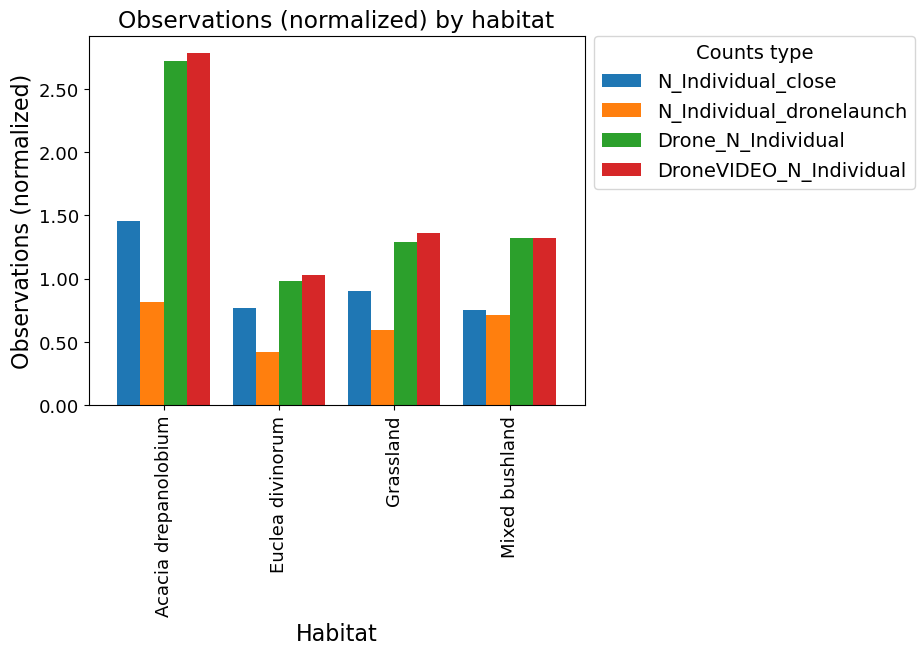

In [29]:
# 2. VEGETATION TYPE VS COUNTS TYPE

# Filter the data to include only the specified categories in 'counts_type'
filtered_data = data[data['counts_type'].isin(['N_Individual_close', 'N_Individual_dronelaunch', 'Drone_N_Individual', 'DroneVIDEO_N_Individual'])]

# Pivot the data to get the sum of counts for each 'vegetation' and 'counts_type'
cols = ['N_Individual_close', 'N_Individual_dronelaunch',
        'Drone_N_Individual', 'DroneVIDEO_N_Individual']
pivoted_data = (
    filtered_data
    .pivot_table(index='vegetation', columns='counts_type',
                 values='total_count', aggfunc='sum')
    .reindex(columns=cols, fill_value=0)  # keep only these, in this order
)

# Calculate the observation counts for normalization
observation_counts = filtered_data.groupby('vegetation').size()

# Normalize the data
normalized_data = pivoted_data.div(observation_counts, axis=0)

# Plot the grouped bar chart
normalized_data.plot(kind='bar', width=0.8)
plt.legend(title='Counts type', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

# Set the labels and title
plt.xlabel('Habitat')
plt.ylabel('Observations (normalized)')
plt.title('Observations (normalized) by habitat')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# Save and show the plot
plt.savefig('habitat_observability.png', bbox_inches='tight')
plt.show()

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/1069281793.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/1069281793.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


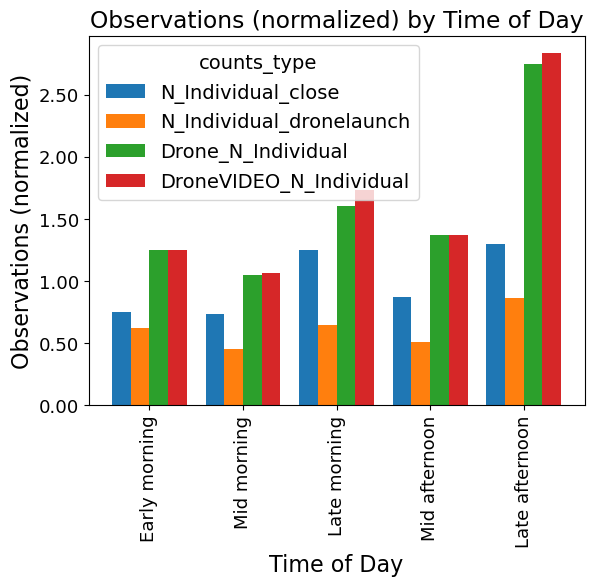

In [30]:
# 3. TIME OF THE DAY VS COUNTS TYPE

# Filter the data to include only the specified categories in 'counts_type'
filtered_data = data[data['counts_type'].isin(['N_Individual_close', 'N_Individual_dronelaunch', 'Drone_N_Individual', 'DroneVIDEO_N_Individual'])]

# Pivot the data to get the sum of counts for each 'Time_Category' and 'counts_type'
cols = ['N_Individual_close', 'N_Individual_dronelaunch',
        'Drone_N_Individual', 'DroneVIDEO_N_Individual']
pivoted_data = (
    filtered_data
    .pivot_table(index='Time_Category', columns='counts_type',
                 values='total_count', aggfunc='sum')
    .reindex(columns=cols, fill_value=0)  # keep only these, in this order
)
# Calculate the observation counts for normalization
observation_counts = filtered_data.groupby('Time_Category').size()

# Normalize the data
normalized_data = pivoted_data.div(observation_counts, axis=0)

# Plot the grouped bar chart
normalized_data.plot(kind='bar', width=0.8)

# Set the labels and title
plt.xlabel('Time of Day')
plt.ylabel('Observations (normalized)')
plt.title('Observations (normalized) by Time of Day')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# Save and show the plot
plt.savefig('time_observability.png', bbox_inches='tight')
plt.show()

# **Modeling**

In this section, we set up our models. The dependent variable is always the numerical 'total_count', which represents the sum of individuals counted for every observation.
Every observation coincides with a type of count (these are 4: ground close count '_close_', ground far count '_dronelaunch_', drone count '_Drone_', drone recording count '_DroneVIDEO_') that is related to a) the overall count of individuals without distinction of sex or age, or b) the count of individuals belonging to specific sex/age classes (here: adult female, adult male and cubs).

**Counts type**
   In these models, we evaluate solely the effect of the 4 types of counts on the overall individual count or on the individual count differentiated for sex/age classes

Total count (**INDIVIDUALS**) ~ counts type + random factor Cluster_ID 

Total count (**ADULT FEMALES**) ~ counts type + random factor Cluster_ID

Total count (**ADULT MALES**) ~ counts type + random factor Cluster_ID

Total count (**CUBS**) ~ counts type + random factor Cluster_ID

**Vegetation type**
   Here we evaluate the effect of different vegetation types ('Euclea divinorum', 'Acacia drepanolobium', 'Grassland', 'Mixed bushland') on the total count of individuals made by drone recording 
   
1. Total count by drone recording (INDIVIDUALS) ~ vegetation type + random factor Cluster_ID

**Time of the day**
   Here we evaluate the effect of different times of the day ('Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon') on the total count of individuals made by drone recording 
   
2. Total count by drone recording (INDIVIDUALS) ~ time of the day + random factor Cluster_ID, fam=NEGATIVE BINOMIAL distribution

3. Total count by drone recording (INDIVIDUALS) ~ time of the day + random factor Cluster_ID, fam=POISSON distribution

4. Total count by drone recording (INDIVIDUALS) ~ time of the day circular (Sin and Cos) + random factor Cluster_ID

**Vegetation type and time of the day**
Here we evaluate the additive and combine effect of different vegetation types and times of the day, also testing the impact of every observation as a random factor, on the total count of individuals by drone recording

5. Total count by drone recording (INDIVIDUALS) ~ time of the day + vegetation type + random factor Cluster_ID

6. Total count by drone recording (INDIVIDUALS) ~ time of the day + vegetation type + vegetation type*time of the day + random factor Cluster_ID

7. Total count by drone recording (INDIVIDUALS) ~ time of the day circular (Sin and Cos) + vegetation type + random factor Cluster_ID

8. Total count by drone recording (INDIVIDUALS) ~ time of the day circular (Sin and Cos) + vegetation type + vegetation type*time of the day circular (Sin and Cos) + random factor Cluster_ID


## **Counts type**

In [5]:
# ============================================================
# Total count – INDIVIDUALS
# Negative Binomial GLMM with centered log-offset (Drone VIDEO)
# ============================================================

# ------------------------
# Configuration
# ------------------------
best_method = 'DroneVIDEO_N_Individual'
other_methods = [
    'N_Individual_close',
    'N_Individual_dronelaunch',
    'Drone_N_Individual'
]

# ------------------------
# Build drone effort per event (Cluster_ID + Test_ID)
# ------------------------
video_by_event = (
    data.loc[
        data['counts_type'] == best_method,
        ['Cluster_ID', 'Test_ID', 'total_count']
    ]
    .groupby(['Cluster_ID', 'Test_ID'], as_index=False)
    .max()
    .rename(columns={'total_count': 'drone_count'})
)

# ------------------------
# Keep only non-video methods and merge drone effort
# ------------------------
filt_data = data[data['counts_type'].isin(other_methods)].copy()
filt_data = filt_data.merge(
    video_by_event,
    on=['Cluster_ID', 'Test_ID'],
    how='left'
)

# ------------------------
# Ensure numeric drone effort
# ------------------------
filt_data['drone_count'] = pd.to_numeric(
    filt_data['drone_count'],
    errors='coerce'
)

# Drop invalid values introduced by coercion
bad_mask = filt_data['drone_count'].isna() | (filt_data['drone_count'] <= 0)
if bad_mask.any():
    print("Dropping rows with invalid drone_count:")
    print(
        filt_data.loc[
            bad_mask,
            ['Cluster_ID', 'Test_ID', 'counts_type', 'drone_count']
        ].to_string(index=False)
    )
    filt_data = filt_data.loc[~bad_mask].copy()

# ------------------------
# Centered log-offset
# ------------------------
filt_data['log_drone'] = np.log(filt_data['drone_count'].to_numpy())
filt_data['log_drone_centered'] = (
    filt_data['log_drone'] - filt_data['log_drone'].mean()
)



# ------------------------
# Types
# ------------------------
filt_data['counts_type'] = filt_data['counts_type'].astype('category')
filt_data['Cluster_ID']  = filt_data['Cluster_ID'].astype('category')
filt_data['Test_ID']     = filt_data['Test_ID'].astype('category')
filt_data['total_count'] = filt_data['total_count'].astype(int)

# ------------------------
# Centered log-offset
# ------------------------
filt_data['log_drone'] = np.log(filt_data['drone_count'])
filt_data['log_drone_centered'] = (
    filt_data['log_drone'] - filt_data['log_drone'].mean()
)

# ------------------------
# Model
# ------------------------
model_individual_nb = bmb.Model(
    'total_count ~ counts_type + offset(log_drone_centered) '
    '+ (1 + counts_type | Cluster_ID)',
    data=filt_data,
    family='negativebinomial',
)

# ------------------------
# Fit
# ------------------------
results_individual_nb = model_individual_nb.fit(
    chains=4,
    cores=4,
    draws=1000,
    tune=1000,
    target_accept=0.9,
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# ------------------------
# Diagnostics
# ------------------------
summary_individual_nb = az.summary(results_individual_nb)
n_chains = results_individual_nb.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_individual_nb)

issues = summary_individual_nb[
    (summary_individual_nb["ess_bulk"] < ess_threshold) |
    (summary_individual_nb["ess_tail"] < ess_threshold) |
    (summary_individual_nb["r_hat"] >= 1.01)
]

if not issues.empty:
    print(
        f"\nWarning: Some parameters did not meet convergence criteria "
        f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01)."
    )
    print(issues)

    try:
        n_divergences = int(
            results_individual_nb.sample_stats["diverging"].sum().values
        )
        if n_divergences > 0:
            print(
                f"\nDivergences detected: {n_divergences}. "
                "Consider stronger priors or increasing target_accept "
                "(e.g., 0.95)."
            )
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, counts_type, 1|Cluster_ID_sigma, 1|Cluster_ID_offset, counts_type|Cluster_ID_sigma, counts_type|Cluster_ID_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


                                                        mean         sd  \
alpha                                               2933.308  40628.629   
Intercept                                              1.584      0.050   
counts_type[N_Individual_close]                       -0.504      0.133   
counts_type[N_Individual_dronelaunch]                 -0.971      0.129   
1|Cluster_ID_sigma                                     0.055      0.043   
...                                                      ...        ...   
counts_type|Cluster_ID[N_Individual_dronelaunch...    -0.202      0.349   
counts_type|Cluster_ID[N_Individual_dronelaunch...     0.192      0.355   
counts_type|Cluster_ID[N_Individual_dronelaunch...     0.303      0.350   
counts_type|Cluster_ID[N_Individual_dronelaunch...     0.050      0.331   
counts_type|Cluster_ID[N_Individual_dronelaunch...     0.076      0.348   

                                                    hdi_3%   hdi_97%  \
alpha                      

In [212]:
# ============================================================
# Total count – Females
# Negative Binomial GLMM with centered log-offset (Drone VIDEO)
# ============================================================

# ------------------------
# Configuration
# ------------------------
best_method = 'DroneVIDEO_N_F'
other_methods = [
    'N_F_close',
    'N_F_dronelaunch',
    'Drone_N_F'
]

# ------------------------
# Build drone effort per event (Cluster_ID + Test_ID)
# ------------------------
video_by_event = (
    data.loc[
        data['counts_type'] == best_method,
        ['Cluster_ID', 'Test_ID', 'total_count']
    ]
    .groupby(['Cluster_ID', 'Test_ID'], as_index=False)
    .max()
    .rename(columns={'total_count': 'drone_count'})
)

# ------------------------
# Keep only non-video methods and merge drone effort
# ------------------------
filt_data = data[data['counts_type'].isin(other_methods)].copy()
filt_data = filt_data.merge(
    video_by_event,
    on=['Cluster_ID', 'Test_ID'],
    how='left'
)

# ------------------------
# Ensure numeric drone effort
# ------------------------
filt_data['drone_count'] = pd.to_numeric(
    filt_data['drone_count'],
    errors='coerce'
)

bad_mask = filt_data['drone_count'].isna() | (filt_data['drone_count'] <= 0)
if bad_mask.any():
    print("Dropping rows with invalid drone_count:")
    print(
        filt_data.loc[
            bad_mask,
            ['Cluster_ID', 'Test_ID', 'counts_type', 'drone_count']
        ].to_string(index=False)
    )
    filt_data = filt_data.loc[~bad_mask].copy()

# ------------------------
# Centered log-offset
# ------------------------
filt_data['log_drone'] = np.log(filt_data['drone_count'].to_numpy())
filt_data['log_drone_centered'] = (
    filt_data['log_drone'] - filt_data['log_drone'].mean()
)

# ------------------------
# Types
# ------------------------
filt_data['counts_type'] = filt_data['counts_type'].astype('category')
filt_data['Cluster_ID']  = filt_data['Cluster_ID'].astype('category')
filt_data['Test_ID']     = filt_data['Test_ID'].astype('category')
filt_data['total_count'] = filt_data['total_count'].astype(int)

# ------------------------
# Model
# ------------------------
model_F_nb = bmb.Model(
    'total_count ~ counts_type + offset(log_drone_centered) + (1 + counts_type | Cluster_ID)',
    data=filt_data,
    family='negativebinomial',
)

# ------------------------
# Fit
# ------------------------
results_F_nb = model_F_nb.fit(
    chains=4,
    cores=4,
    draws=1000,
    tune=1000,
    target_accept=0.9,
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# ------------------------
# Diagnostics
# ------------------------
summary_F_nb = az.summary(results_F_nb)
n_chains = results_F_nb.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_F_nb)

issues = summary_F_nb[
    (summary_F_nb["ess_bulk"] < ess_threshold) |
    (summary_F_nb["ess_tail"] < ess_threshold) |
    (summary_F_nb["r_hat"] >= 1.01)
]

if not issues.empty:
    print(
        f"\nWarning: Some parameters did not meet convergence criteria "
        f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01)."
    )
    print(issues)

    try:
        n_divergences = int(
            results_F_nb.sample_stats["diverging"].sum().values
        )
        if n_divergences > 0:
            print(
                f"\nDivergences detected: {n_divergences}. "
                "Consider stronger priors or increasing target_accept "
                "(e.g., 0.95)."
            )
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")


import pandas as pd


with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.width', None):
    print(summary_F_nb.to_string())


Dropping rows with invalid drone_count:
Cluster_ID Test_ID     counts_type  drone_count
   UTx0811    UT01       N_F_close            0
   WAx1211    WA01       N_F_close            0
   WAx2511    WA10       N_F_close            0
   WAx2511    WA11       N_F_close            0
   UTx0811    UT01 N_F_dronelaunch            0
   WAx1211    WA01 N_F_dronelaunch            0
   WAx2511    WA10 N_F_dronelaunch            0
   WAx2511    WA11 N_F_dronelaunch            0
   UTx0811    UT01       Drone_N_F            0
   WAx1211    WA01       Drone_N_F            0
   WAx2511    WA10       Drone_N_F            0
   WAx2511    WA11       Drone_N_F            0


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, counts_type, 1|Cluster_ID_sigma, 1|Cluster_ID_offset, counts_type|Cluster_ID_sigma, counts_type|Cluster_ID_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


                                                      mean         sd  hdi_3%  \
alpha                                             1775.367  27142.193  13.514   
Intercept                                            0.853      0.078   0.712   
counts_type[N_F_close]                              -0.361      0.121  -0.607   
counts_type[N_F_dronelaunch]                        -0.839      0.147  -1.110   
1|Cluster_ID_sigma                                   0.071      0.054   0.000   
...                                                    ...        ...     ...   
counts_type|Cluster_ID[N_F_dronelaunch, UTx2611]    -0.000      0.213  -0.425   
counts_type|Cluster_ID[N_F_dronelaunch, WAx1211]     0.005      0.240  -0.487   
counts_type|Cluster_ID[N_F_dronelaunch, WAx2211]     0.102      0.235  -0.292   
counts_type|Cluster_ID[N_F_dronelaunch, WAx2311]     0.034      0.230  -0.379   
counts_type|Cluster_ID[N_F_dronelaunch, WAx2511]     0.012      0.238  -0.461   

                           

In [7]:
# ============================================================
# Total count – Males
# Negative Binomial GLMM with centered log-offset (Drone VIDEO)
# ============================================================

best_method = 'DroneVIDEO_N_M'
other_methods = [
    'N_M_close',
    'N_M_dronelaunch',
    'Drone_N_M'
]

video_by_event = (
    data.loc[
        data['counts_type'] == best_method,
        ['Cluster_ID', 'Test_ID', 'total_count']
    ]
    .groupby(['Cluster_ID', 'Test_ID'], as_index=False)
    .max()
    .rename(columns={'total_count': 'drone_count'})
)

filt_data = data[data['counts_type'].isin(other_methods)].copy()
filt_data = filt_data.merge(
    video_by_event,
    on=['Cluster_ID', 'Test_ID'],
    how='left'
)

filt_data['drone_count'] = pd.to_numeric(
    filt_data['drone_count'],
    errors='coerce'
)

bad_mask = filt_data['drone_count'].isna() | (filt_data['drone_count'] <= 0)
if bad_mask.any():
    filt_data = filt_data.loc[~bad_mask].copy()

filt_data['log_drone'] = np.log(filt_data['drone_count'].to_numpy())
filt_data['log_drone_centered'] = (
    filt_data['log_drone'] - filt_data['log_drone'].mean()
)

filt_data['counts_type'] = filt_data['counts_type'].astype('category')
filt_data['Cluster_ID']  = filt_data['Cluster_ID'].astype('category')
filt_data['Test_ID']     = filt_data['Test_ID'].astype('category')
filt_data['total_count'] = filt_data['total_count'].astype(int)

model_M_nb = bmb.Model(
    'total_count ~ counts_type + offset(log_drone_centered) + (1 + counts_type | Cluster_ID)',
    data=filt_data,
    family='negativebinomial',
)

results_M_nb = model_M_nb.fit(
    chains=4,
    cores=4,
    draws=1000,
    tune=1000,
    target_accept=0.9,
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

summary_M_nb = az.summary(results_M_nb)
n_chains = results_M_nb.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_M_nb)

issues = summary_M_nb[
    (summary_M_nb["ess_bulk"] < ess_threshold) |
    (summary_M_nb["ess_tail"] < ess_threshold) |
    (summary_M_nb["r_hat"] >= 1.01)
]

if not issues.empty:
    print(issues)
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, counts_type, 1|Cluster_ID_sigma, 1|Cluster_ID_offset, counts_type|Cluster_ID_sigma, counts_type|Cluster_ID_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


                                                     mean        sd  hdi_3%  \
alpha                                             712.367  5795.083   9.627   
Intercept                                           0.397     0.117   0.168   
counts_type[N_M_close]                             -0.182     0.179  -0.516   
counts_type[N_M_dronelaunch]                       -0.566     0.201  -0.961   
1|Cluster_ID_sigma                                  0.092     0.074   0.000   
...                                                   ...       ...     ...   
counts_type|Cluster_ID[N_M_dronelaunch, UTx1911]   -0.057     0.223  -0.525   
counts_type|Cluster_ID[N_M_dronelaunch, UTx2111]   -0.043     0.239  -0.547   
counts_type|Cluster_ID[N_M_dronelaunch, WAx1211]    0.029     0.219  -0.368   
counts_type|Cluster_ID[N_M_dronelaunch, WAx2311]   -0.062     0.224  -0.524   
counts_type|Cluster_ID[N_M_dronelaunch, WAx2511]   -0.020     0.226  -0.453   

                                                   

In [8]:
# ============================================================
# Total count – cubs
# Negative Binomial GLMM with centered log-offset (Drone VIDEO)
# ============================================================

best_method = 'DroneVIDEO_N_c'
other_methods = [
    'N_c_close',
    'N_c_dronelaunch',
    'Drone_N_c'
]

video_by_event = (
    data.loc[
        data['counts_type'] == best_method,
        ['Cluster_ID', 'Test_ID', 'total_count']
    ]
    .groupby(['Cluster_ID', 'Test_ID'], as_index=False)
    .max()
    .rename(columns={'total_count': 'drone_count'})
)

filt_data = data[data['counts_type'].isin(other_methods)].copy()
filt_data = filt_data.merge(
    video_by_event,
    on=['Cluster_ID', 'Test_ID'],
    how='left'
)

filt_data['drone_count'] = pd.to_numeric(
    filt_data['drone_count'],
    errors='coerce'
)

bad_mask = filt_data['drone_count'].isna() | (filt_data['drone_count'] <= 0)
if bad_mask.any():
    filt_data = filt_data.loc[~bad_mask].copy()

filt_data['log_drone'] = np.log(filt_data['drone_count'].to_numpy())
filt_data['log_drone_centered'] = (
    filt_data['log_drone'] - filt_data['log_drone'].mean()
)

filt_data['counts_type'] = filt_data['counts_type'].astype('category')
filt_data['Cluster_ID']  = filt_data['Cluster_ID'].astype('category')
filt_data['Test_ID']     = filt_data['Test_ID'].astype('category')
filt_data['total_count'] = filt_data['total_count'].astype(int)

model_c_nb = bmb.Model(
    'total_count ~ counts_type + offset(log_drone_centered) + (1 + counts_type | Cluster_ID)',
    data=filt_data,
    family='negativebinomial',
)

results_c_nb = model_c_nb.fit(
    chains=4,
    cores=4,
    draws=1000,
    tune=1000,
    target_accept=0.95,
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

summary_c_nb = az.summary(results_c_nb)
n_chains = results_c_nb.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_c_nb)

issues = summary_c_nb[
    (summary_c_nb["ess_bulk"] < ess_threshold) |
    (summary_c_nb["ess_tail"] < ess_threshold) |
    (summary_c_nb["r_hat"] >= 1.01)
]

if not issues.empty:
    print(issues)
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, counts_type, 1|Cluster_ID_sigma, 1|Cluster_ID_offset, counts_type|Cluster_ID_sigma, counts_type|Cluster_ID_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


                                                     mean        sd  hdi_3%  \
alpha                                             660.900  9674.245   5.667   
Intercept                                           1.535     0.101   1.346   
counts_type[N_c_close]                             -1.572     0.636  -2.853   
counts_type[N_c_dronelaunch]                       -2.146     0.590  -3.266   
1|Cluster_ID_sigma                                  0.138     0.107   0.000   
counts_type|Cluster_ID_sigma[N_c_close]             1.743     0.756   0.650   
counts_type|Cluster_ID_sigma[N_c_dronelaunch]       1.470     0.678   0.463   
1|Cluster_ID[AJx0212]                               0.028     0.122  -0.196   
1|Cluster_ID[AJx0711]                               0.030     0.139  -0.261   
1|Cluster_ID[AJx0811]                               0.023     0.126  -0.221   
1|Cluster_ID[AJx0911]                               0.004     0.142  -0.271   
1|Cluster_ID[AJx1311]                              -

## **Vegetation type**

In [6]:
# 1 TOTAL COUNT BY DRONE RECORDING (INDIVIDUALS) ~ VEGETATION TYPE

# Filter to the selected category and work on a copy
categories = ['DroneVIDEO_N_Individual']
filt_data = data[data['counts_type'].isin(categories)].copy()

# Ensure predictors/response types
filt_data['Cluster_ID']  = filt_data['Cluster_ID'].astype('category')
filt_data['counts_type'] = filt_data['counts_type'].astype('category')
filt_data['vegetation'] = filt_data['vegetation'].astype('category')
filt_data['vegetation'] = filt_data['vegetation'].cat.reorder_categories(
    ['Euclea divinorum', 'Acacia drepanolobium', 'Grassland', 'Mixed bushland'],
    ordered=True
)
filt_data['total_count'] = filt_data['total_count'].astype(int)

# Optional: sanity check non-negative counts for Negative Binomial
if (filt_data['total_count'] < 0).any():
    raise ValueError("total_count contains negative values; Negative Binomial requires non-negative counts.")

# Build model
model_individual9 = bmb.Model(
    'total_count ~ vegetation + (1 | Cluster_ID)',
    data=filt_data,
    family='negativebinomial'
)

# Fit once with fixed settings
results_individual9 = model_individual9.fit(
    chains=4,
    cores=4,
    draws=2000,         # post-tune draws per chain
    tune=2000,          # warmup
    target_accept=0.95,  # consider 0.95 if divergences occur
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary_individual9 = az.summary(results_individual9)
n_chains = results_individual9.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_individual9)

issues = summary_individual9[
    (summary_individual9["ess_bulk"] < ess_threshold) |
    (summary_individual9["ess_tail"] < ess_threshold) |
    (summary_individual9["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results_individual9.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, vegetation, 1|Cluster_ID_sigma, 1|Cluster_ID_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3 seconds.


                                      mean          sd  hdi_3%   hdi_97%  \
alpha                             9834.672  559700.091   5.398  1712.405   
Intercept                            1.434       0.186   1.067     1.762   
vegetation[Acacia drepanolobium]     0.693       0.251   0.212     1.167   
vegetation[Grassland]                0.189       0.247  -0.292     0.627   
vegetation[Mixed bushland]           0.272       0.299  -0.302     0.823   
1|Cluster_ID_sigma                   0.649       0.123   0.435     0.880   
1|Cluster_ID[AJx0212]                0.576       0.270   0.068     1.076   
1|Cluster_ID[AJx0711]               -0.172       0.278  -0.695     0.353   
1|Cluster_ID[AJx0811]                0.518       0.270  -0.007     1.002   
1|Cluster_ID[AJx0911]                0.463       0.312  -0.081     1.090   
1|Cluster_ID[AJx1311]                0.660       0.308   0.092     1.262   
1|Cluster_ID[AJx1411]                0.882       0.246   0.441     1.370   
1|Cluster_ID

## **Time of the day**

In [7]:
# 2 TOTAL COUNT BY DRONE RECORDING (INDIVIDUALS) ~ TIME OF THE DAY 
# NEGATIVE BINOMIAL

# Filter to the selected category and work on a copy
categories = ['DroneVIDEO_N_Individual']
filt_data = data[data['counts_type'].isin(categories)].copy()

# Ensure predictors/response types
filt_data['Cluster_ID']  = filt_data['Cluster_ID'].astype('category')
filt_data['counts_type'] = filt_data['counts_type'].astype('category')
filt_data['Time_Category'] = filt_data['Time_Category'].astype('category')
filt_data['Time_Category'] = filt_data['Time_Category'].cat.reorder_categories(
    ['Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon'],
    ordered=True
)
filt_data['total_count'] = filt_data['total_count'].astype(int)

# Optional: sanity check non-negative counts for Negative Binomial
if (filt_data['total_count'] < 0).any():
    raise ValueError("total_count contains negative values; Negative Binomial requires non-negative counts.")

# Build model
model_individual4 = bmb.Model(
    'total_count ~ Time_Category + (1 | Cluster_ID)',
    data=filt_data,
    family='negativebinomial'
)

# Fit once with fixed settings
results_individual4 = model_individual4.fit(
    chains=4,
    cores=4,
    draws=2000,         # post-tune draws per chain
    tune=2000,          # warmup
    target_accept=0.95,  # consider 0.95 if divergences occur
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary_individual4 = az.summary(results_individual4)
n_chains = results_individual4.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_individual4)

issues = summary_individual4[
    (summary_individual4["ess_bulk"] < ess_threshold) |
    (summary_individual4["ess_tail"] < ess_threshold) |
    (summary_individual4["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results_individual4.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, Time_Category, 1|Cluster_ID_sigma, 1|Cluster_ID_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


                                  mean        sd  hdi_3%   hdi_97%  mcse_mean  \
alpha                          592.272  3172.110   7.303  1401.541     50.664   
Intercept                        1.534     0.409   0.755     2.289      0.008   
Time_Category[Mid morning]      -0.091     0.375  -0.791     0.625      0.006   
Time_Category[Late morning]      0.149     0.427  -0.658     0.924      0.008   
Time_Category[Mid afternoon]     0.236     0.464  -0.610     1.142      0.010   
Time_Category[Late afternoon]    0.455     0.462  -0.395     1.325      0.010   
1|Cluster_ID_sigma               0.729     0.133   0.498     0.982      0.003   
1|Cluster_ID[AJx0212]            0.810     0.277   0.309     1.341      0.005   
1|Cluster_ID[AJx0711]            0.283     0.300  -0.293     0.833      0.005   
1|Cluster_ID[AJx0811]            0.653     0.294   0.098     1.203      0.005   
1|Cluster_ID[AJx0911]            0.596     0.339  -0.049     1.219      0.005   
1|Cluster_ID[AJx1311]       

In [8]:
# 3 TOTAL COUNT BY DRONE RECORDING (INDIVIDUALS) ~ TIME OF THE DAY 
# POISSON

# Filter to the selected category and work on a copy
categories = ['DroneVIDEO_N_Individual']
filt_data = data[data['counts_type'].isin(categories)].copy()

# Ensure predictors/response types
filt_data['Cluster_ID']  = filt_data['Cluster_ID'].astype('category')
filt_data['counts_type'] = filt_data['counts_type'].astype('category')
filt_data['Time_Category'] = filt_data['Time_Category'].astype('category')
filt_data['Time_Category'] = filt_data['Time_Category'].cat.reorder_categories(
    ['Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon'],
    ordered=True
)
filt_data['total_count'] = filt_data['total_count'].astype(int)

# Optional: sanity check non-negative counts for Negative Binomial
if (filt_data['total_count'] < 0).any():
    raise ValueError("total_count contains negative values; Negative Binomial requires non-negative counts.")

# Build model
model_individual5 = bmb.Model(
    'total_count ~ Time_Category + (1 | Cluster_ID)',
    data=filt_data,
    family='poisson'
)

# Fit once with fixed settings
results_individual5 = model_individual5.fit(
    chains=4,
    cores=4,
    draws=2000,         # post-tune draws per chain
    tune=2000,          # warmup
    target_accept=0.95,  # consider 0.95 if divergences occur
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary_individual5 = az.summary(results_individual5)
n_chains = results_individual5.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_individual5)

issues = summary_individual5[
    (summary_individual5["ess_bulk"] < ess_threshold) |
    (summary_individual5["ess_tail"] < ess_threshold) |
    (summary_individual5["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results_individual5.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, Time_Category, 1|Cluster_ID_sigma, 1|Cluster_ID_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3 seconds.


                                mean     sd  hdi_3%  hdi_97%  mcse_mean  \
Intercept                      1.564  0.404   0.802    2.318      0.009   
Time_Category[Mid morning]    -0.102  0.361  -0.771    0.583      0.006   
Time_Category[Late morning]    0.130  0.416  -0.720    0.844      0.008   
Time_Category[Mid afternoon]   0.216  0.470  -0.721    1.061      0.011   
Time_Category[Late afternoon]  0.420  0.473  -0.471    1.293      0.011   
1|Cluster_ID_sigma             0.736  0.130   0.509    0.984      0.003   
1|Cluster_ID[AJx0212]          0.815  0.272   0.294    1.318      0.005   
1|Cluster_ID[AJx0711]          0.272  0.294  -0.265    0.835      0.005   
1|Cluster_ID[AJx0811]          0.663  0.284   0.137    1.194      0.005   
1|Cluster_ID[AJx0911]          0.609  0.328   0.001    1.229      0.005   
1|Cluster_ID[AJx1311]          0.626  0.312   0.041    1.209      0.006   
1|Cluster_ID[AJx1411]          1.094  0.249   0.622    1.551      0.005   
1|Cluster_ID[AJx1811]    

In [9]:
# 4 TOTAL COUNT BY DRONE RECORDING (INDIVIDUALS) ~ TIME OF THE DAY CIRCULAR


# Filter to the selected category and work on a copy
categories = ['DroneVIDEO_N_Individual']
filt_data = data[data['counts_type'].isin(categories)].copy()

# Ensure predictors/response types
filt_data['Cluster_ID']  = filt_data['Cluster_ID'].astype('category')
filt_data['counts_type'] = filt_data['counts_type'].astype('category')
filt_data['total_count'] = filt_data['total_count'].astype(int)

# Optional: enforce numeric Time_Sin/Cos
# If they are not numeric already, coerce to numeric (NaNs if invalid)
# import pandas as pd
# filt_data['Time_Sin'] = pd.to_numeric(filt_data['Time_Sin'], errors='coerce')
# filt_data['Time_Cos'] = pd.to_numeric(filt_data['Time_Cos'], errors='coerce')

# Optional: sanity check non-negative counts for count likelihoods
if (filt_data['total_count'] < 0).any():
    raise ValueError("total_count contains negative values; count models require non-negative counts.")

# Build model
model_individual3 = bmb.Model(
    'total_count ~ Time_Sin + Time_Cos + (1 | Cluster_ID)',
    data=filt_data,
    family='negativebinomial'  # change to 'negativebinomial' if desired
)

# Fit once with fixed settings
results_individual3 = model_individual3.fit(
    chains=4,
    cores=4,
    draws=2000,         # post-tune draws per chain
    tune=2000,          # warmup
    target_accept=0.95,  # consider 0.95 if divergences occur
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary_individual3 = az.summary(results_individual3)
n_chains = results_individual3.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_individual3)

issues = summary_individual3[
    (summary_individual3["ess_bulk"] < ess_threshold) |
    (summary_individual3["ess_tail"] < ess_threshold) |
    (summary_individual3["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results_individual3.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, standardizing predictors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, Time_Sin, Time_Cos, 1|Cluster_ID_sigma, 1|Cluster_ID_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


                          mean        sd  hdi_3%   hdi_97%  mcse_mean  \
alpha                  680.099  4371.400  12.018  1506.127     66.580   
Intercept                1.948     0.376   1.260     2.673      0.007   
Time_Sin                -0.134     0.288  -0.681     0.394      0.005   
Time_Cos                 0.438     0.466  -0.430     1.331      0.008   
1|Cluster_ID_sigma       0.741     0.131   0.514     0.992      0.003   
1|Cluster_ID[AJx0212]    0.734     0.273   0.229     1.258      0.005   
1|Cluster_ID[AJx0711]    0.386     0.300  -0.193     0.928      0.005   
1|Cluster_ID[AJx0811]    0.620     0.291   0.047     1.143      0.005   
1|Cluster_ID[AJx0911]    0.518     0.352  -0.169     1.158      0.005   
1|Cluster_ID[AJx1311]    0.778     0.301   0.205     1.325      0.005   
1|Cluster_ID[AJx1411]    1.023     0.253   0.554     1.504      0.005   
1|Cluster_ID[AJx1811]    0.825     0.279   0.294     1.343      0.005   
1|Cluster_ID[AJx2111]    0.760     0.310   0.166   

## **Vegetation type and time of the day**

In [10]:
# 5 TOTAL COUNT BY DRONE RECORDING (INDIVIDUALS) ~ VEGETATION TYPE + TIME OF THE DAY


# Filter to the selected category and work on a copy
categories = ['DroneVIDEO_N_Individual']
filt_data = data[data['counts_type'].isin(categories)].copy()

# Ensure predictors/response types
filt_data['Cluster_ID'] = filt_data['Cluster_ID'].astype('str')
filt_data['counts_type'] = filt_data['counts_type'].astype('category')

filt_data['vegetation'] = filt_data['vegetation'].astype('category')
filt_data['vegetation'] = filt_data['vegetation'].cat.reorder_categories(
    ['Euclea divinorum', 'Acacia drepanolobium', 'Grassland', 'Mixed bushland'],
    ordered=True
)

filt_data['Time_Category'] = filt_data['Time_Category'].astype('category')
filt_data['Time_Category'] = filt_data['Time_Category'].cat.reorder_categories(
    ['Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon'],
    ordered=True
)

filt_data['total_count'] = filt_data['total_count'].astype(int)

# Optional: sanity check non-negative counts for Negative Binomial
if (filt_data['total_count'] < 0).any():
    raise ValueError("total_count contains negative values; Negative Binomial requires non-negative counts.")

# Build model
model_individual14 = bmb.Model(
    'total_count ~ vegetation + Time_Category + ( 1 | Cluster_ID)',
    data=filt_data,
    family='negativebinomial'
)

# Fit once with fixed settings
results_individual14 = model_individual14.fit(
    chains=4,
    cores=4,
    draws=2000,         # post-tune draws per chain
    tune=2000,          # warmup
    target_accept=0.95,  # consider 0.95 if divergences occur
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary_individual14 = az.summary(results_individual14)
n_chains = results_individual14.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_individual14)

issues = summary_individual14[
    (summary_individual14["ess_bulk"] < ess_threshold) |
    (summary_individual14["ess_tail"] < ess_threshold) |
    (summary_individual14["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results_individual14.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, vegetation, Time_Category, 1|Cluster_ID_sigma, 1|Cluster_ID_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


                                     mean         sd  hdi_3%   hdi_97%  \
alpha                             781.331  17656.617   5.580  1272.037   
Intercept                           1.141      0.451   0.307     1.994   
vegetation[Acacia drepanolobium]    0.780      0.246   0.310     1.232   
vegetation[Grassland]               0.173      0.241  -0.279     0.625   
vegetation[Mixed bushland]          0.302      0.324  -0.324     0.893   
Time_Category[Mid morning]         -0.095      0.428  -0.895     0.716   
Time_Category[Late morning]         0.341      0.450  -0.491     1.176   
Time_Category[Mid afternoon]        0.255      0.466  -0.671     1.073   
Time_Category[Late afternoon]       0.483      0.468  -0.351     1.385   
1|Cluster_ID_sigma                  0.579      0.123   0.370     0.809   
1|Cluster_ID[AJx0212]               0.415      0.279  -0.111     0.933   
1|Cluster_ID[AJx0711]              -0.181      0.301  -0.733     0.386   
1|Cluster_ID[AJx0811]               0.

In [11]:
# 6 TOTAL COUNT BY DRONE RECORDING (INDIVIDUALS) ~ VEGETATION TYPE + TIME OF THE DAY + VEGETATION TYPE*TIME OF THE DAY

# Filter to the selected category and work on a copy
categories = ['DroneVIDEO_N_Individual']
filt_data = data[data['counts_type'].isin(categories)].copy()

# Ensure predictors/response types
filt_data['Cluster_ID'] = filt_data['Cluster_ID'].astype('str')
filt_data['counts_type'] = filt_data['counts_type'].astype('category')

filt_data['vegetation'] = filt_data['vegetation'].astype('category')
filt_data['vegetation'] = filt_data['vegetation'].cat.reorder_categories(
    ['Euclea divinorum', 'Acacia drepanolobium', 'Grassland', 'Mixed bushland'],
    ordered=True
)

filt_data['Time_Category'] = filt_data['Time_Category'].astype('category')
filt_data['Time_Category'] = filt_data['Time_Category'].cat.reorder_categories(
    ['Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon'],
    ordered=True
)

filt_data['total_count'] = filt_data['total_count'].astype(int)

# Optional: sanity check non-negative counts for Negative Binomial
if (filt_data['total_count'] < 0).any():
    raise ValueError("total_count contains negative values; Negative Binomial requires non-negative counts.")

# Build model with interaction
model_individual13 = bmb.Model(
    'total_count ~ vegetation + Time_Category + vegetation:Time_Category + (1 | Cluster_ID)',
    data=filt_data,
    family='negativebinomial'
)

# Fit once with fixed settings
results_individual13 = model_individual13.fit(
    chains=4,
    cores=4,
    draws=2000,         # post-tune draws per chain
    tune=2000,          # warmup
    target_accept=0.95,  # consider 0.95 if divergences occur
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary_individual13 = az.summary(results_individual13)
n_chains = results_individual13.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_individual13)

issues = summary_individual13[
    (summary_individual13["ess_bulk"] < ess_threshold) |
    (summary_individual13["ess_tail"] < ess_threshold) |
    (summary_individual13["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results_individual13.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, vegetation, Time_Category, vegetation:Time_Category, 1|Cluster_ID_sigma, 1|Cluster_ID_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 40 seconds.


                                                       mean        sd  hdi_3%  \
alpha                                               464.790  3430.813   5.400   
Intercept                                             1.054     0.615  -0.146   
vegetation[Acacia drepanolobium]                      0.459     3.446  -6.148   
vegetation[Grassland]                                -0.007     4.360  -8.180   
vegetation[Mixed bushland]                            0.463     0.739  -0.926   
Time_Category[Mid morning]                           -0.001     0.610  -1.165   
Time_Category[Late morning]                           0.554     0.674  -0.737   
Time_Category[Mid afternoon]                          0.457     0.702  -0.848   
Time_Category[Late afternoon]                         0.365     0.771  -1.024   
vegetation:Time_Category[Acacia drepanolobium, ...    0.119     3.465  -6.420   
vegetation:Time_Category[Acacia drepanolobium, ...   -0.227     3.461  -6.772   
vegetation:Time_Category[Aca

In [12]:
# 7 TOTAL COUNT BY DRONE RECORDING (INDIVIDUALS) ~ time of the day circular (Sin and Cos) + vegetation type + random factor Cluster_ID


# Filter to the selected category and work on a copy
categories = ['DroneVIDEO_N_Individual']
filt_data = data[data['counts_type'].isin(categories)].copy()

# Ensure predictors/response types
filt_data['Cluster_ID'] = filt_data['Cluster_ID'].astype('str')
filt_data['counts_type'] = filt_data['counts_type'].astype('category')

filt_data['vegetation'] = filt_data['vegetation'].astype('category')
filt_data['vegetation'] = filt_data['vegetation'].cat.reorder_categories(
    ['Euclea divinorum', 'Acacia drepanolobium', 'Grassland', 'Mixed bushland'],
    ordered=True
)


filt_data['total_count'] = filt_data['total_count'].astype(int)

# Optional: sanity check non-negative counts for Negative Binomial
if (filt_data['total_count'] < 0).any():
    raise ValueError("total_count contains negative values; Negative Binomial requires non-negative counts.")

# Build model
model_individual15 = bmb.Model(
    'total_count ~ vegetation + Time_Cos + Time_Sin + (1 | Cluster_ID)',
    data=filt_data,
    family="negativebinomial"
)

# Fit once with fixed settings
results_individual15 = model_individual15.fit(
    chains=4,
    cores=4,
    draws=2000,         # post-tune draws per chain
    tune=2000,          # warmup
    target_accept=0.95,  # consider 0.95 if divergences occur
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary_individual15 = az.summary(results_individual15)
n_chains = results_individual15.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_individual15)

issues = summary_individual15[
    (summary_individual15["ess_bulk"] < ess_threshold) |
    (summary_individual15["ess_tail"] < ess_threshold) |
    (summary_individual15["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results_individual14.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, vegetation, Time_Cos, Time_Sin, 1|Cluster_ID_sigma, 1|Cluster_ID_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 5 seconds.


                                      mean         sd  hdi_3%   hdi_97%  \
alpha                             1050.328  24758.429  10.185  1560.254   
Intercept                            1.506      0.397   0.786     2.271   
vegetation[Acacia drepanolobium]     0.666      0.255   0.180     1.146   
vegetation[Grassland]                0.173      0.252  -0.309     0.633   
vegetation[Mixed bushland]           0.302      0.310  -0.286     0.869   
Time_Cos                             0.241      0.453  -0.611     1.095   
Time_Sin                            -0.202      0.276  -0.726     0.307   
1|Cluster_ID_sigma                   0.638      0.124   0.420     0.870   
1|Cluster_ID[AJx0212]                0.413      0.287  -0.138     0.942   
1|Cluster_ID[AJx0711]                0.023      0.315  -0.565     0.616   
1|Cluster_ID[AJx0811]                0.320      0.296  -0.253     0.871   
1|Cluster_ID[AJx0911]                0.258      0.337  -0.382     0.898   
1|Cluster_ID[AJx1311]    

In [13]:
# 8 TOTAL COUNT BY DRONE RECORDING (INDIVIDUALS) ~ time of the day circular (Sin and Cos) + vegetation type 
# + vegetation type*time of the day circular (Sin and Cos) + random factor Cluster_ID

# Filter to the selected category and work on a copy
categories = ['DroneVIDEO_N_Individual']
filt_data = data[data['counts_type'].isin(categories)].copy()

# Ensure predictors/response types
filt_data['Cluster_ID'] = filt_data['Cluster_ID'].astype('str')
filt_data['counts_type'] = filt_data['counts_type'].astype('category')

filt_data['vegetation'] = filt_data['vegetation'].astype('category')
filt_data['vegetation'] = filt_data['vegetation'].cat.reorder_categories(
    ['Euclea divinorum', 'Acacia drepanolobium', 'Grassland', 'Mixed bushland'],
    ordered=True
)


filt_data['total_count'] = filt_data['total_count'].astype(int)

# Optional: sanity check non-negative counts for Negative Binomial
if (filt_data['total_count'] < 0).any():
    raise ValueError("total_count contains negative values; Negative Binomial requires non-negative counts.")

# Build model with interaction
model_individual18 = bmb.Model(
    'total_count ~ vegetation + Time_Sin + Time_Cos + vegetation:(Time_Sin + Time_Cos) + (1 | Cluster_ID)',
    data=filt_data,
    family='negativebinomial'
)

# Fit once with fixed settings
results_individual18 = model_individual18.fit(
    chains=4,
    cores=4,
    draws=2000,         # post-tune draws per chain
    tune=2000,          # warmup
    target_accept=0.95,  # consider 0.95 if divergences occur
    random_seed=42,
    idata_kwargs=dict(log_likelihood=True),
)

# Diagnostics: ESS threshold is 100 * number of chains; also check r_hat < 1.01
summary_individual18 = az.summary(results_individual18)
n_chains = results_individual18.posterior.sizes["chain"]
ess_threshold = 100 * n_chains

print(summary_individual18)

issues = summary_individual18[
    (summary_individual18["ess_bulk"] < ess_threshold) |
    (summary_individual18["ess_tail"] < ess_threshold) |
    (summary_individual18["r_hat"] >= 1.01)
]

if not issues.empty:
    print(f"\nWarning: Some parameters did not meet convergence criteria "
          f"(ESS_bulk/tail >= {ess_threshold}, r_hat < 1.01).")
    print(issues)

    # Optional: report divergences to inform reparameterization/model review
    try:
        n_divergences = int(results_individual18.sample_stats["diverging"].sum().values)
        if n_divergences > 0:
            print(f"\nDivergences detected: {n_divergences}. Consider reparameterization, "
                  "adding/adjusting priors, or increasing target_accept (e.g., 0.95).")
    except Exception:
        pass
else:
    print(f"\nAll parameters meet ESS >= {ess_threshold} and r_hat < 1.01.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, vegetation, Time_Sin, Time_Cos, vegetation:Time_Sin, vegetation:Time_Cos, 1|Cluster_ID_sigma, 1|Cluster_ID_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 11 seconds.


                                              mean         sd  hdi_3%  \
alpha                                      856.266  15057.067   6.977   
Intercept                                    1.190      0.612   0.081   
vegetation[Acacia drepanolobium]             1.232      0.793  -0.213   
vegetation[Grassland]                       -0.001      1.379  -2.580   
vegetation[Mixed bushland]                  -0.261      0.999  -2.132   
Time_Sin                                    -0.246      0.375  -0.982   
Time_Cos                                    -0.244      0.750  -1.625   
vegetation:Time_Sin[Acacia drepanolobium]    0.007      0.553  -1.018   
vegetation:Time_Sin[Grassland]               0.226      0.995  -1.568   
vegetation:Time_Sin[Mixed bushland]          0.110      0.509  -0.912   
vegetation:Time_Cos[Acacia drepanolobium]    0.964      1.015  -0.948   
vegetation:Time_Cos[Grassland]              -0.276      1.410  -2.920   
vegetation:Time_Cos[Mixed bushland]         -0.778 

# **Model comparison**

In [1]:
# EXTRA
# count models - INDIVIDUALS
# comparison NB model, distributional model, 
# distributional model with priors modified, distributional model with priors modified and random effect on alpha



model_dict = {
    "distributional model": results_individual_nb1, 
    'nb model': results_individual_nb,
    "distributional model modified priors": results_individual_nb_alpha_empirical,
    "distributional model modified priors and random effect on alpha": results_individual_nb_alpha_empirical1
)




# Compare the models
comparison = az.compare(model_dict)

# Print the comparison results
print(comparison)

# Optionally, visualize the comparison
az.plot_compare(comparison)
plt.savefig('comparison_plot_nb_distributional.png', bbox_inches='tight')

NameError: name 'results_individual_nb1' is not defined

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/st

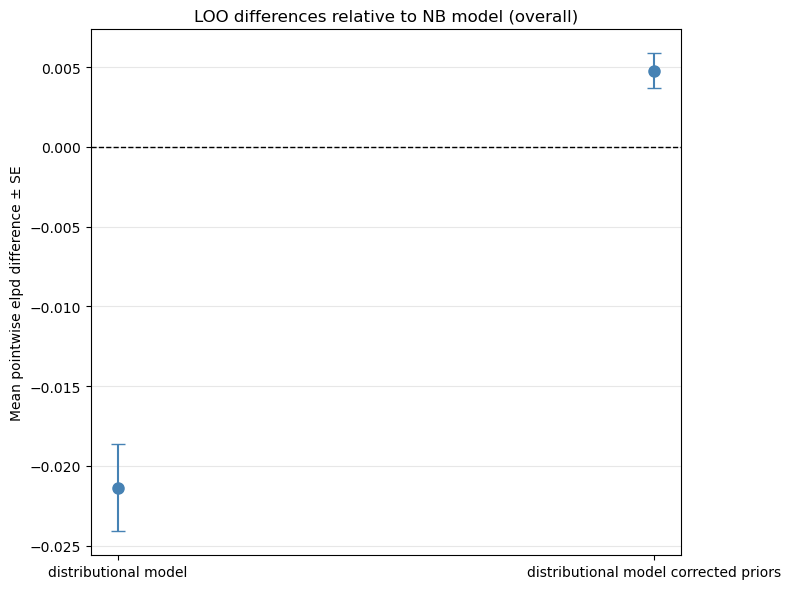

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_1647/1496540399.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


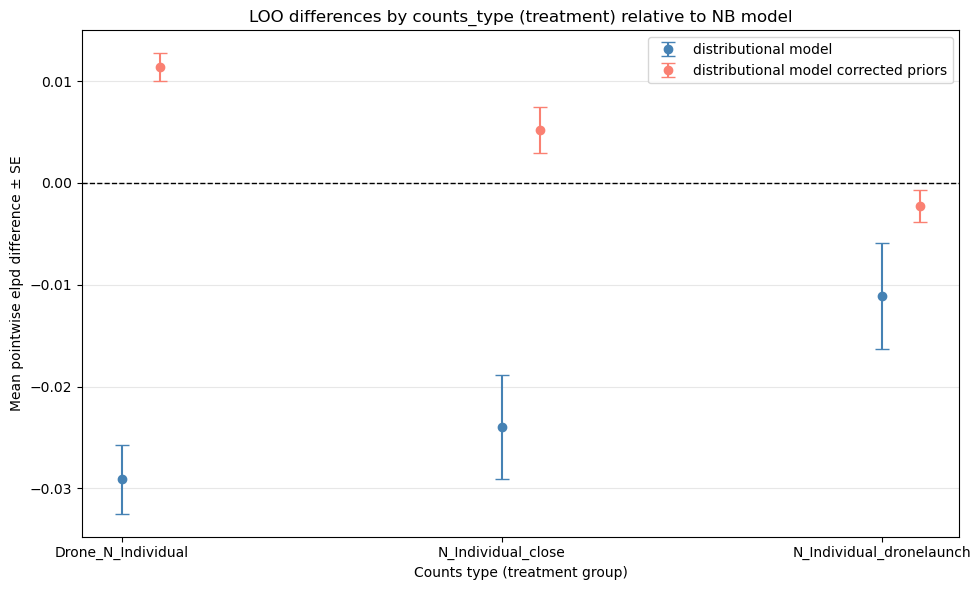

<Figure size 640x480 with 0 Axes>

In [127]:
# EXTRA
# count models - INDIVIDUALS
# comparison NB model, distributional model, 
# distributional model with priors modified, distributional model with priors modified and random effect on alpha



# ------------------------
# Models dictionary (InferenceData)
# ------------------------
model_dict = {
    "distributional model": results_individual_nb1, 
    "nb model": results_individual_nb,
    "distributional model corrected priors": results_individual_nb_alpha_empirical
}

# ------------------------
# Compute pointwise LOO for all models
# ------------------------
loo_dict = {name: az.loo(idata, pointwise=True) for name, idata in model_dict.items()}

# ------------------------
# Compute differences relative to reference model ('nb model')
# ------------------------
ref_name = 'nb model'
loo_ref = loo_dict[ref_name].loo_i

diff_df = pd.DataFrame()
for name, loo_obj in loo_dict.items():
    if name == ref_name:
        continue
    diff_df[name] = loo_obj.loo_i - loo_ref

# ------------------------
# Overall mean ± SE per model
# ------------------------
summary = diff_df.apply(lambda col: pd.Series({
    'mean': np.mean(col),
    'se': np.std(col) / np.sqrt(len(col))
})).T  # transpose so rows = models

plt.figure(figsize=(8,6))
plt.errorbar(x=summary.index, y=summary['mean'], yerr=summary['se'], fmt='o', 
             capsize=5, markersize=8, linestyle='None', color='steelblue')
plt.axhline(0, color='black', linestyle='--', lw=1)
plt.ylabel("Mean pointwise elpd difference ± SE")
plt.title("LOO differences relative to NB model (overall)")
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ------------------------
# Stratify by counts_type (treatment)
# ------------------------
treatment = filt_data['counts_type'].values  # matches loo_i
diff_df_treatment = diff_df.copy()
diff_df_treatment['treatment'] = treatment

# Compute mean ± SE per treatment for each model
treatment_summary = diff_df_treatment.groupby('treatment').agg(
    **{f"{col}_mean": (col, 'mean') for col in diff_df.columns},
    **{f"{col}_se": (col, lambda x: np.std(x)/np.sqrt(len(x))) for col in diff_df.columns}
)

# Plot mean ± SE per treatment
plt.figure(figsize=(10,6))
colors = ['steelblue', 'salmon', 'lightgreen']

for i, model in enumerate(diff_df.columns):
    means = treatment_summary[f"{model}_mean"]
    ses = treatment_summary[f"{model}_se"]
    # Slightly offset x for each model to avoid overlap
    x = np.arange(len(treatment_summary)) + i*0.1
    plt.errorbar(x, means, yerr=ses, fmt='o', capsize=5, label=model, color=colors[i])

plt.axhline(0, color='black', linestyle='--', lw=1)
plt.xticks(np.arange(len(treatment_summary)), treatment_summary.index)
plt.xlabel("Counts type (treatment group)")
plt.ylabel("Mean pointwise elpd difference ± SE")
plt.title("LOO differences by counts_type (treatment) relative to NB model")
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("loo_difference_by_treatment.png", dpi=300, bbox_inches="tight")  # <-- save
plt.show()


plt.savefig("elpd difference2.png",dpi=300, bbox_inches="tight")
plt.show()


/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/st

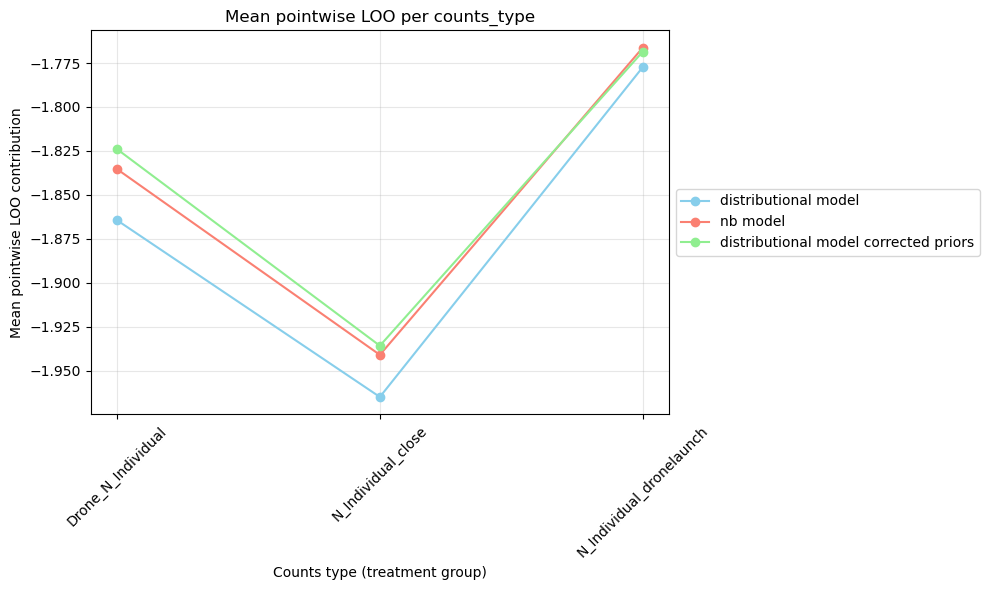

In [128]:
# EXTRA
# count models - INDIVIDUALS
# comparison NB model, distributional model, 
# distributional model with priors modified, distributional model with priors modified and random effect on alpha

# Models dictionary
model_dict = {
    "distributional model": results_individual_nb1, 
    "nb model": results_individual_nb,
    "distributional model corrected priors": results_individual_nb_alpha_empirical
}

# Reference data for grouping
filt_data_subset = filt_data[['counts_type']].copy()

# Compute pointwise LOO for all models
loo_dict = {name: az.loo(idata, pointwise=True) for name, idata in model_dict.items()}

# Aggregate mean LOO per treatment (counts_type)
group_means = {}
for name, loo_obj in loo_dict.items():
    loo_i = loo_obj.loo_i
    df_tmp = filt_data_subset.copy()
    df_tmp['loo_i'] = loo_i
    mean_per_group = df_tmp.groupby('counts_type')['loo_i'].mean()
    group_means[name] = mean_per_group

# Combine into DataFrame for plotting
group_means_df = pd.DataFrame(group_means)

# ------------------------
# Plot mean pointwise elpd per treatment
# ------------------------
plt.figure(figsize=(10,6))
colors = ['skyblue', 'salmon', 'lightgreen', 'gold']
for color, col in zip(colors, group_means_df.columns):
    plt.plot(group_means_df.index, group_means_df[col], marker='o', label=col, color=color)

plt.xlabel("Counts type (treatment group)")
plt.ylabel("Mean pointwise LOO contribution")
plt.title("Mean pointwise LOO per counts_type")
plt.xticks(rotation=45)
plt.legend(loc='center left', bbox_to_anchor=(1,0.5))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/st

                                                    rank    elpd_loo  \
Time (Sin+Cos), fam = NB                               0 -145.836339   
Time (categorical), fam = Poisson                      1 -146.213615   
Vegetation, fam = NB                                   2 -147.755778   
Time (Sin+Cos) + Vegetation, fam = NB                  3 -148.165248   
Time (categorical), fam = NB                           4 -148.306725   
Time (categorical) + Vegetation, fam = NB              5 -150.806406   
Time (Sin+Cos) + Vegetation + Time (Sin+Cos) x ...     6 -151.810410   
Time (categorical) + Vegetation + Time (categor...     7 -159.039101   

                                                        p_loo  elpd_diff  \
Time (Sin+Cos), fam = NB                             9.145632   0.000000   
Time (categorical), fam = Poisson                   10.865044   0.377276   
Vegetation, fam = NB                                10.356479   1.919440   
Time (Sin+Cos) + Vegetation, fam = NB          

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/stats/st

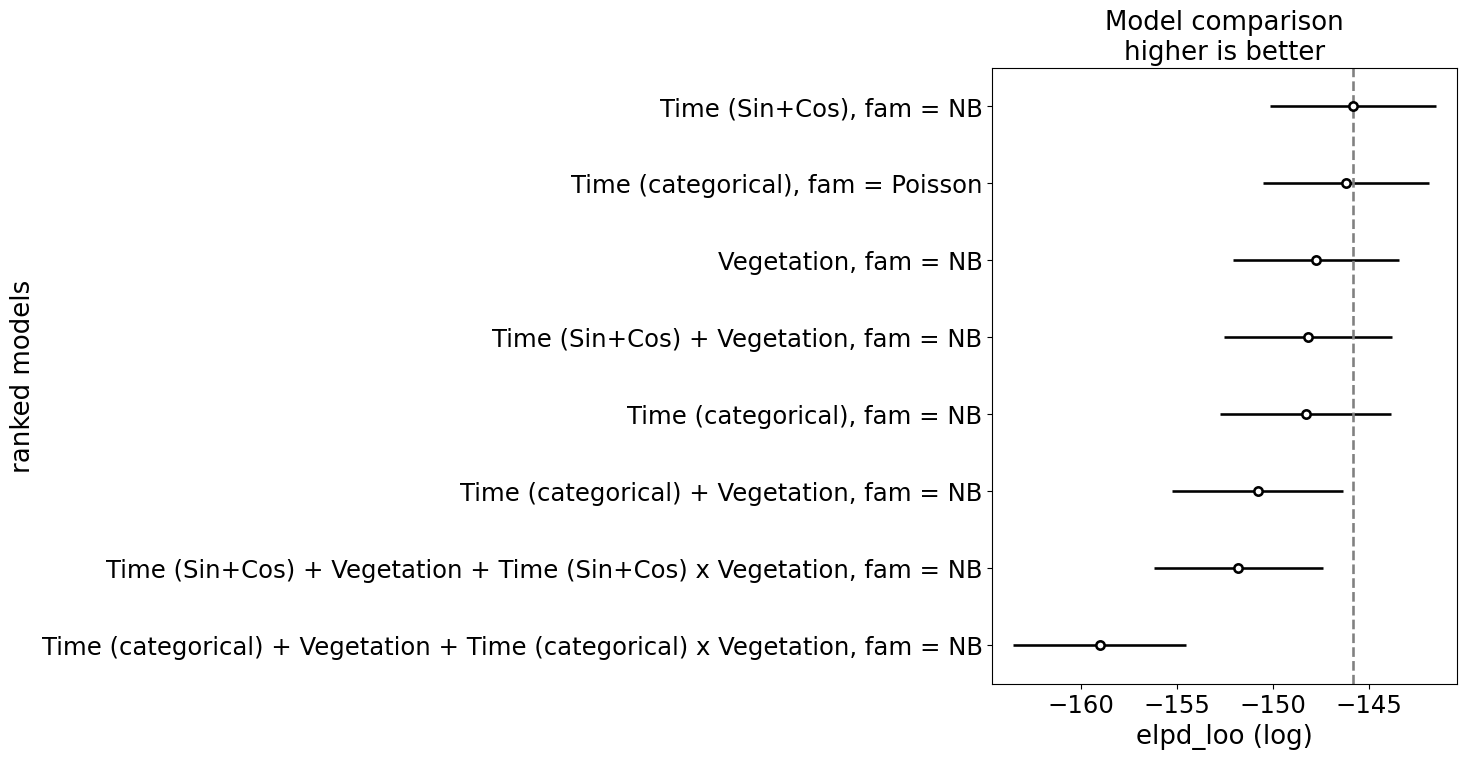

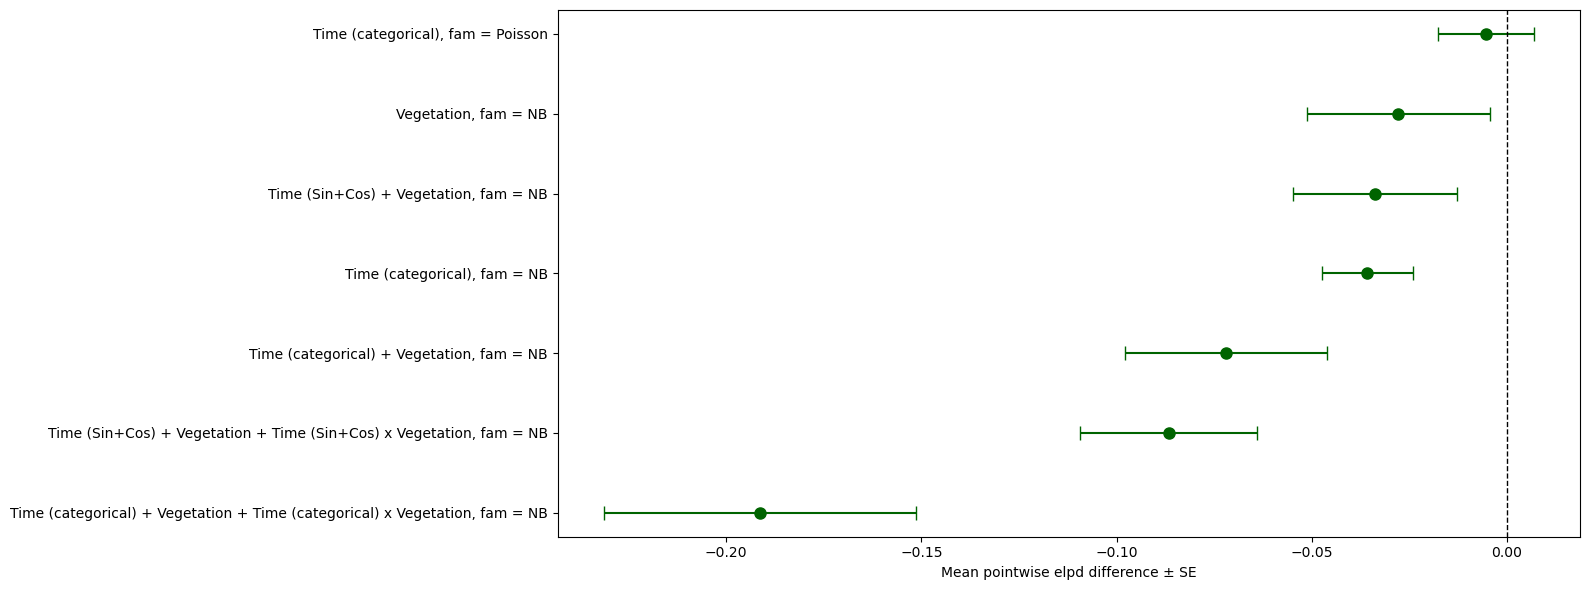

In [14]:
# model comparison
# time of the day and vegetation models

model_dict = {
    "Time (Sin+Cos), fam = NB": results_individual3, # Sin and Cos + cluster id
    "Time (categorical), fam = NB": results_individual4, 
    "Time (categorical), fam = Poisson": results_individual5, # Time category + cluster id 
    "Vegetation, fam = NB": results_individual9, # vegetation + cluster id
    "Time (categorical) + Vegetation, fam = NB": results_individual14,
    "Time (categorical) + Vegetation + Time (categorical) x Vegetation, fam = NB": results_individual13,
    "Time (Sin+Cos) + Vegetation, fam = NB": results_individual15,
    "Time (Sin+Cos) + Vegetation + Time (Sin+Cos) x Vegetation, fam = NB": results_individual18
}

# Compare the models
comparison = az.compare(model_dict)

# Print the comparison results
print(comparison)

# Optionally, visualize the comparison
az.plot_compare(comparison)
plt.savefig('comparison_plot_Observability2.png', bbox_inches='tight')

# ------------------------
# Compute pointwise LOO for all models
# ------------------------
loo_dict = {
    name: az.loo(idata, pointwise=True)
    for name, idata in model_dict.items()
}
# ------------------------
# Compute differences relative to reference model
# ------------------------
ref_name = "Time (Sin+Cos), fam = NB"
loo_ref = loo_dict[ref_name].loo_i

diff_df = pd.DataFrame()
for name, loo_obj in loo_dict.items():
    if name == ref_name:
        continue
    diff_df[name] = loo_obj.loo_i - loo_ref
# ------------------------
# Overall mean ± SE per model
# ------------------------
summary = diff_df.apply(
    lambda col: pd.Series({
        "mean": np.mean(col),
        "se": np.std(col) / np.sqrt(len(col))
    })
).T

# Sort models by absolute mean difference (closest to 0 first)
summary_sorted = summary.copy()
summary_sorted["abs_mean"] = summary_sorted["mean"].abs()
summary_sorted = summary_sorted.sort_values("abs_mean", ascending=False)


plt.figure(figsize=(16, 6))

plt.errorbar(
    x=summary_sorted["mean"],
    y=summary_sorted.index,
    xerr=summary_sorted["se"],
    fmt="o",
    capsize=5,
    markersize=8,
    linestyle="None",
    color="darkgreen"
)

# Vertical reference line at 0
# X-axis ticks every 5.0

plt.axvline(0, color="black", linestyle="--", lw=1)

plt.xlabel("Mean pointwise elpd difference ± SE")

plt.tight_layout()
plt.savefig(
    "loo_difference_overall_time_veg_horizontal_sorted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig('LOOdifferences_Observability_reviewed.png', bbox_inches='tight')
plt.show()



/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_40969/2234083527.py:68: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.


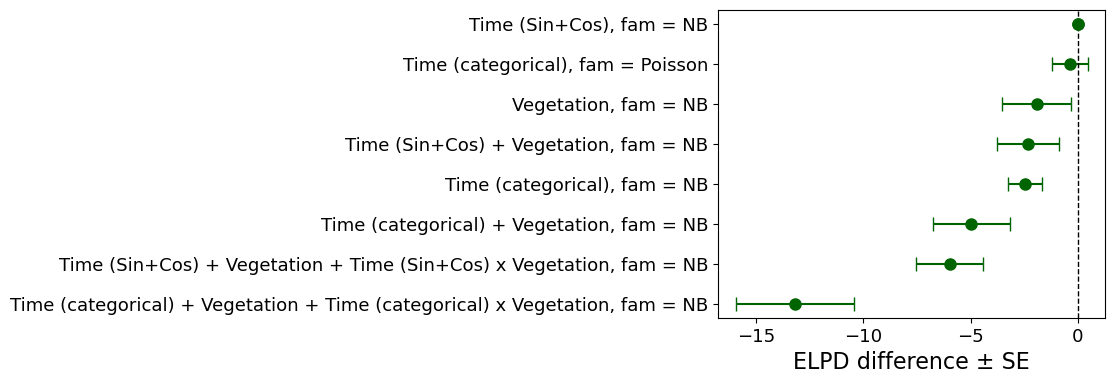

In [16]:
from matplotlib.ticker import MultipleLocator

# ------------------------
# Overall ELPD difference ± SE per model
# ------------------------
summary = diff_df.apply(
    lambda col: pd.Series({
        "elpd_diff": col.sum(),  # SUM, not mean
        "se": np.sqrt(np.sum((col - col.mean())**2))
    })
).T

# Reference (best) model
ref_name = "Time (Sin+Cos), fam = NB"

# 🔑 ADD BEST MODEL BACK (missing before)
summary.loc[ref_name] = {
    "elpd_diff": 0.0,
    "se": np.nan   # ensures NO CI is drawn
}

# Sort models by absolute difference
summary_sorted = summary.copy()
summary_sorted["abs_elpd"] = summary_sorted["elpd_diff"].abs()
summary_sorted = summary_sorted.sort_values("abs_elpd", ascending=False)

# ------------------------
# Plot (KEEP YOUR STYLE)
# ------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

plt.figure(figsize=(5, 4))
ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(5.0))

plt.errorbar(
    x=summary_sorted["elpd_diff"],
    y=summary_sorted.index,
    xerr=summary_sorted["se"],
    fmt="o",
    capsize=5,
    markersize=8,
    linestyle="None",
    color="darkgreen"
)

# 🔑 redraw reference model as clean dot (no CI)
plt.plot(
    0,
    ref_name,
    "o",
    color="darkgreen",
    markersize=8,
    zorder=3
)

# Vertical reference line
plt.axvline(0, color="black", linestyle="--", lw=1)

plt.xlabel("ELPD difference ± SE")

plt.tight_layout()

plt.savefig(
    "loo_ELPD_difference_overall_time_veg_horizontal_sorted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "ELPDdifferences_Observability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# **Observed data vs predicted best models** 

### **Counts type - Individuals**

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 5.2 x 4.2 in image.
/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: <_io.BytesIO object at 0x16a552d90>
/opt/miniconda3/envs/

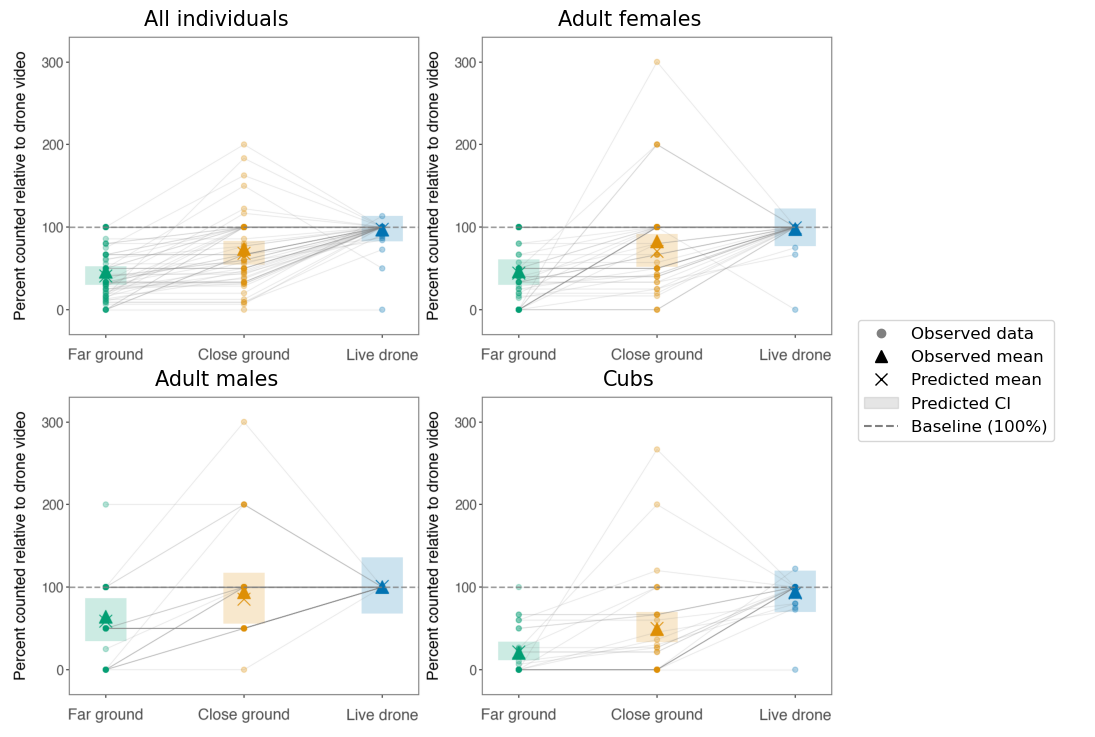

In [117]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from plotnine import (
    ggplot, aes, geom_point, geom_line, geom_rect, geom_hline,
    labs, theme_bw, theme, element_text,
    scale_x_continuous, scale_y_continuous,
    scale_color_manual, scale_fill_manual
)
from matplotlib.colors import to_hex
from PIL import Image
from io import BytesIO

def make_plot_for_suffix_nb(suffix, model, results, data, y_limits=None):

    cb_palette = sns.color_palette("colorblind", 3)
    cb_hex = [to_hex(c) for c in cb_palette]

    # darker palette for mean points (both observed and predicted)
    darker_cb_hex = [to_hex(sns.dark_palette(c, n_colors=1)[0]) for c in cb_palette]

    best_method = f'DroneVIDEO_N_{suffix}'
    other_methods = [
        f'N_{suffix}_dronelaunch',
        f'N_{suffix}_close',
        f'Drone_N_{suffix}'
    ]

    label_map = {
        other_methods[0]: 'Far ground',
        other_methods[1]: 'Close ground',
        other_methods[2]: 'Live drone'
    }

    # ------------------------
    # Observed data
    # ------------------------
    video_by_event = (
        data.loc[data['counts_type'] == best_method,
                 ['Cluster_ID', 'Test_ID', 'total_count']]
        .groupby(['Cluster_ID', 'Test_ID'], as_index=False)
        .max()
        .rename(columns={'total_count': 'drone_count'})
    )

    fd = data[data['counts_type'].isin(other_methods)].copy()
    fd = fd.merge(video_by_event, on=['Cluster_ID', 'Test_ID'], how='left')
    fd = fd[fd['drone_count'].notna() & (fd['drone_count'] > 0)]

    fd['counts_type'] = fd['counts_type'].astype('category')
    fd['observed_mult'] = fd['total_count'] / fd['drone_count']

    # ------------------------
    # Posterior predictive
    # ------------------------
    ppd = model.predict(results, kind='pps', inplace=False)
    varname = list(ppd.posterior_predictive.data_vars)[0]
    ppd_array = ppd.posterior_predictive[varname].values

    n_obs = fd.shape[0]
    ppd_flat = ppd_array.reshape(-1, n_obs)
    ppd_mult = ppd_flat / fd['drone_count'].to_numpy()

    posterior_mean_by_method = {}

    for ct in fd['counts_type'].cat.categories:
        idx = fd['counts_type'] == ct
        draw_means = ppd_mult[:, idx.values].mean(axis=1)

        posterior_mean_by_method[ct] = {
            'pred_mean': draw_means.mean(),
            'pred_low': np.percentile(draw_means, 2.5),
            'pred_high': np.percentile(draw_means, 97.5)
        }

    summary_fd = (
        fd.groupby('counts_type', observed=True)
          .agg(obs_mean=('observed_mult', 'mean'))
          .reset_index()
    )

    summary_fd['pred_mean'] = summary_fd['counts_type'].map(
        lambda c: posterior_mean_by_method[c]['pred_mean']
    )
    summary_fd['pred_low'] = summary_fd['counts_type'].map(
        lambda c: posterior_mean_by_method[c]['pred_low']
    )
    summary_fd['pred_high'] = summary_fd['counts_type'].map(
        lambda c: posterior_mean_by_method[c]['pred_high']
    )

    summary_fd[['obs_mean', 'pred_mean', 'pred_low', 'pred_high']] = (
        summary_fd[['obs_mean', 'pred_mean', 'pred_low', 'pred_high']]
        .apply(pd.to_numeric)
    )

    pos_map = {cat: i + 1 for i, cat in enumerate(other_methods)}

    fd['xnum'] = fd['counts_type'].map(pos_map).astype(float)
    summary_fd['xnum'] = summary_fd['counts_type'].map(pos_map).astype(float)

    bar_half_width = 0.15
    summary_fd['xmin'] = summary_fd['xnum'] - bar_half_width
    summary_fd['xmax'] = summary_fd['xnum'] + bar_half_width

    fd['unit'] = fd['Cluster_ID'].astype(str) + "_" + fd['Test_ID'].astype(str)

    # Map counts_type to darker color for mean points
    mean_color_map = dict(zip(other_methods, darker_cb_hex))

    # ------------------------
    # Plot
    # ------------------------
    p_out = (
        ggplot()
        + geom_rect(
            data=summary_fd,
            mapping=aes(
                xmin='xmin', xmax='xmax',
                ymin='pred_low * 100',
                ymax='pred_high * 100',
                fill='counts_type'
            ),
            alpha=0.2
        )
        + geom_line(
            data=fd,
            mapping=aes(x='xnum', y='observed_mult * 100', group='unit'),
            color='gray', alpha=0.2, size=0.4
        )
        + geom_point(
            data=fd,
            mapping=aes(x='xnum', y='observed_mult * 100', color='counts_type'),
            size=2.2, alpha=0.3
        )
        + geom_point(
            data=summary_fd,
            mapping=aes(x='xnum', y='pred_mean * 100', color='counts_type'),
            size=6, shape='x'
        )
        + geom_point(
            data=summary_fd,
            mapping=aes(x='xnum', y='obs_mean * 100', color='counts_type'),
            size=6, shape='^'
        )
        + geom_hline(
            yintercept=100,
            linetype='dashed',
            color='gray',
            size=0.8,
            alpha=0.8
        )
        + scale_x_continuous(
            breaks=list(pos_map.values()),
            labels=[label_map[c] for c in other_methods]
        )
        + scale_y_continuous(
            limits=[-10, 300] if y_limits is None else [y_limits[0]*100-30, y_limits[1]*100],
        expand=(0, 0)
        )
        + scale_color_manual(values=cb_hex)
        + scale_fill_manual(values=cb_hex)
        + labs(y='Percent counted relative to drone video', x='')
        + theme_bw()
        + theme(
            axis_text_x=element_text(size=14, margin={'t':10}),
            axis_text_y=element_text(size=12),
            axis_title_y=element_text(size=14, margin={'r': 12}),
            figure_size=(5.2, 4.2),
            legend_position='none',
            panel_grid_major=element_text(alpha=0),
            panel_grid_minor=element_text(alpha=0)
        )
    )

    return p_out


# ------------------------
# Generate plots
# ------------------------
plots = [
    make_plot_for_suffix_nb('Individual', model_individual_nb, results_individual_nb, data, y_limits=y_limits),
    make_plot_for_suffix_nb('F', model_F_nb, results_F_nb, data, y_limits=y_limits),
    make_plot_for_suffix_nb('M', model_M_nb, results_M_nb, data, y_limits=y_limits),
    make_plot_for_suffix_nb('c', model_c_nb, results_c_nb, data, y_limits=y_limits)
]

titles = ["All individuals", "Adult females", "Adult males", "Cubs"]

# ------------------------
# Convert ggplots to images
# ------------------------
images = []
for p in plots:
    buf = BytesIO()
    p.save(buf, format='png', width=5.2, height=4.2, dpi=150)
    buf.seek(0)
    images.append(Image.open(buf))

# ------------------------
# Create 2x2 panel + legend
# ------------------------
fig = plt.figure(figsize=(14,9))
gs = fig.add_gridspec(2,3, width_ratios=[1,1,0.6], wspace=-0.05, hspace=0.08)

axes = [
    fig.add_subplot(gs[0,0]),
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[1,0]),
    fig.add_subplot(gs[1,1]),
    fig.add_subplot(gs[:,2])
]

for i, (ax, img, title) in enumerate(zip(axes[:4], images, titles)):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(title, fontsize=15)

    # Remove x-axis text for top row
    if i < 2:
        ax.set_xticks([])
    # Remove y-axis title for right column
    if i % 2 == 1:
        ax.set_ylabel('')

legend_ax = axes[4]
legend_ax.axis('off')

legend_elements = [
    Line2D([0],[0], marker='o', color='gray', label='Observed data', markersize=6, linestyle=''),
    Line2D([0],[0], marker='^', color='black', label='Observed mean', markersize=8, linestyle=''),
    Line2D([0],[0], marker='x', color='black', label='Predicted mean', markersize=8, linestyle=''),
    mpatches.Patch(color='gray', alpha=0.2, label='Predicted CI'),
    Line2D([0],[0], color='gray', linestyle='dashed', label='Baseline (100%)')
]

legend_ax.legend(handles=legend_elements, loc='center', fontsize=12)

plt.show()
fig.savefig("panel_2x2_nb_percentages.png", dpi=150)


### **Model 4**

In [20]:
# Ensure "hour" exists
pred_df['hour'] = (np.degrees(np.arctan2(pred_df['Time_Sin'], pred_df['Time_Cos'])) % 360) / 15
filt_data['hour'] = (np.degrees(np.arctan2(filt_data['Time_Sin'], filt_data['Time_Cos'])) % 360) / 15

# Build segment as a categorical (avoids dtype issues)
def make_segment(s):
    seg = pd.Series(pd.NA, index=s.index, dtype='string')
    seg[(s >= 8) & (s <= 13)]  = '08–13'
    seg[(s >= 15) & (s <= 19)] = '15–19'
    return pd.Categorical(seg, categories=['08–13', '15–19'], ordered=True)

filt_data['segment'] = make_segment(filt_data['hour'])
pred_df['segment']   = make_segment(pred_df['hour'])

# Keep only rows within the two segments
filt_data_seg = filt_data.dropna(subset=['segment']).copy()
pred_df_seg   = pred_df.dropna(subset=['segment']).copy()

for df in (filt_data_seg, pred_df_seg):
    df['segment'] = df['segment'].cat.rename_categories({
        '08–13': 'Morning',
        '15–19': 'Afternoon'
    })

# Colors
palette = sns.color_palette("colorblind", 3).as_hex()
color_obs, color_pred, color_ci = palette

from plotnine import facet_wrap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# Plot
p = (
    ggplot()
    + geom_point(aes(x='hour', y='total_count'), data=filt_data_seg,
                 color=color_obs, alpha=0.6, size=2)
    + geom_line(aes(x='hour', y='pred_mean'), data=pred_df_seg,
                color=color_pred, size=1)
    + geom_ribbon(aes(x='hour', ymin='ci_lower', ymax='ci_upper'),
                  data=pred_df_seg,
                  fill=color_pred,   # <-- FIXED HERE
                  alpha=0.2)
    + facet_wrap('~segment', ncol=2, scales='free_x')
    + scale_x_continuous(breaks=(8,10,12,15,17,19))
    + scale_y_continuous(limits=(0,70))
    + labs(x='Hour of Day', y='Total Individuals')
    + theme_bw()
    + theme(
        figure_size=(8,4),
        axis_text=element_text(size=12),
        axis_title=element_text(size=14),
        strip_text=element_text(size=12),
        legend_position='none'
    )
    + theme(panel_grid=element_blank())
)

fig = p.draw()

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='black', label='Observed data',
           markerfacecolor=color_obs, markersize=8, linestyle='None'),
    Line2D([0], [0], color=color_pred, lw=2, label='Predicted'),
    Patch(facecolor=color_pred, alpha=0.2, label='Predicted CI')
]

fig.legend(handles=legend_elements, loc='right',
           bbox_to_anchor=(1, 0.82), frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

fig.savefig("predicted_vs_observed_time_facets.png", dpi=300)

<Figure size 640x480 with 0 Axes>

### **Model 1**

In [184]:

# ---------------------------
# Prepare prediction DataFrame
# Use the same data used for fitting (or new data)
pred_df = filt_data.copy()

# Make sure Cluster_ID exists as category
pred_df['Cluster_ID'] = pred_df['Cluster_ID'].astype('category')

# ---------------------------
# Generate posterior mean predictions from Bambi
idata_pred = model_individual9.predict(
    results_individual9,
    data=pred_df,
    kind="mean",      # expected value
    inplace=False
)

# ---------------------------
# Extract posterior samples
post = idata_pred.posterior
print(post.data_vars)  # usually contains "mu"

mu = post["mu"]  # dims: chain × draw × obs

# Stack chains/draws into a single dimension
mu_s = mu.stack(sample=("chain", "draw"))  # dims: obs × sample

# Compute mean and 95% CI
pred_mean = mu_s.mean("sample").values
pred_lower = np.quantile(mu_s, 0.025, axis=1)
pred_upper = np.quantile(mu_s, 0.975, axis=1)

# ---------------------------
# Merge with observed data for plotting
plot_data = pred_df.copy()
plot_data["pred_mean"] = pred_mean
plot_data["ci_lower"] = pred_lower
plot_data["ci_upper"] = pred_upper

# ---------------------------
# Prepare colorblind palette
palette = sns.color_palette("colorblind", n_colors=plot_data['vegetation'].nunique())
palette_dict = dict(zip(plot_data['vegetation'].cat.categories, palette))

# ---------------------------
# Create plotnine plot
p = (
    ggplot(plot_data, aes(x='total_count', y='pred_mean', color='vegetation'))
    + geom_point(size=3, alpha=0.7)
    + geom_abline(intercept=0, slope=1, linetype='dashed', color='grey')
    + scale_color_manual(values=palette_dict)
    + theme_bw()
    + labs(
        x='Observed Total Count',
        y='Predicted Mean Count',
        color='Vegetation - observed data'
    )
    + theme( 
        axis_title=element_text(size=14))
    + theme(panel_grid=element_blank())
)

# ---------------------------
# Draw plot and add manual legend for 1:1 line
fig = p.draw()
custom_line = [Line2D([0], [0], color='grey', lw=2, linestyle='--')]
fig.legend(custom_line, ['1:1 Reference Line'], loc='center right', bbox_to_anchor=(0.93, 0.38), frameon=True, fontsize=9)
fig.savefig("predicted_vs_observed_vegetation_legend.png", dpi=400, bbox_inches='tight', pad_inches=0.1)
plt.show()



/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:851: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future


Data variables:
    alpha               (chain, draw) float64 64kB 2.135e+03 15.42 ... 186.5
    Intercept           (chain, draw) float64 64kB 1.462 1.294 ... 1.801 1.718
    vegetation          (chain, draw, vegetation_dim) float64 192kB 0.9021 .....
    1|Cluster_ID_sigma  (chain, draw) float64 64kB 0.4959 0.5368 ... 0.7764
    1|Cluster_ID        (chain, draw, Cluster_ID__factor_dim) float64 2MB 0.2...
    mu                  (chain, draw, __obs__) float64 4MB 5.525 5.525 ... 1.873


# **Posterior distribution counts model**

### **Model INDIVIDUALS**

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (88) in plot_posterior, generating only 40 plots


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'counts_type\nN_Individual_close'}>,
        <Axes: title={'center': 'counts_type\nN_Individual_dronelaunch'}>],
       [<Axes: title={'center': '1|Cluster_ID_sigma'}>,
        <Axes: title={'center': 'counts_type|Cluster_ID_sigma\nN_Individual_close'}>,
        <Axes: title={'center': 'counts_type|Cluster_ID_sigma\nN_Individual_dronelaunch'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0212'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx0711'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0811'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0911'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1311'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx1411'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1811'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2111'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2311'}>

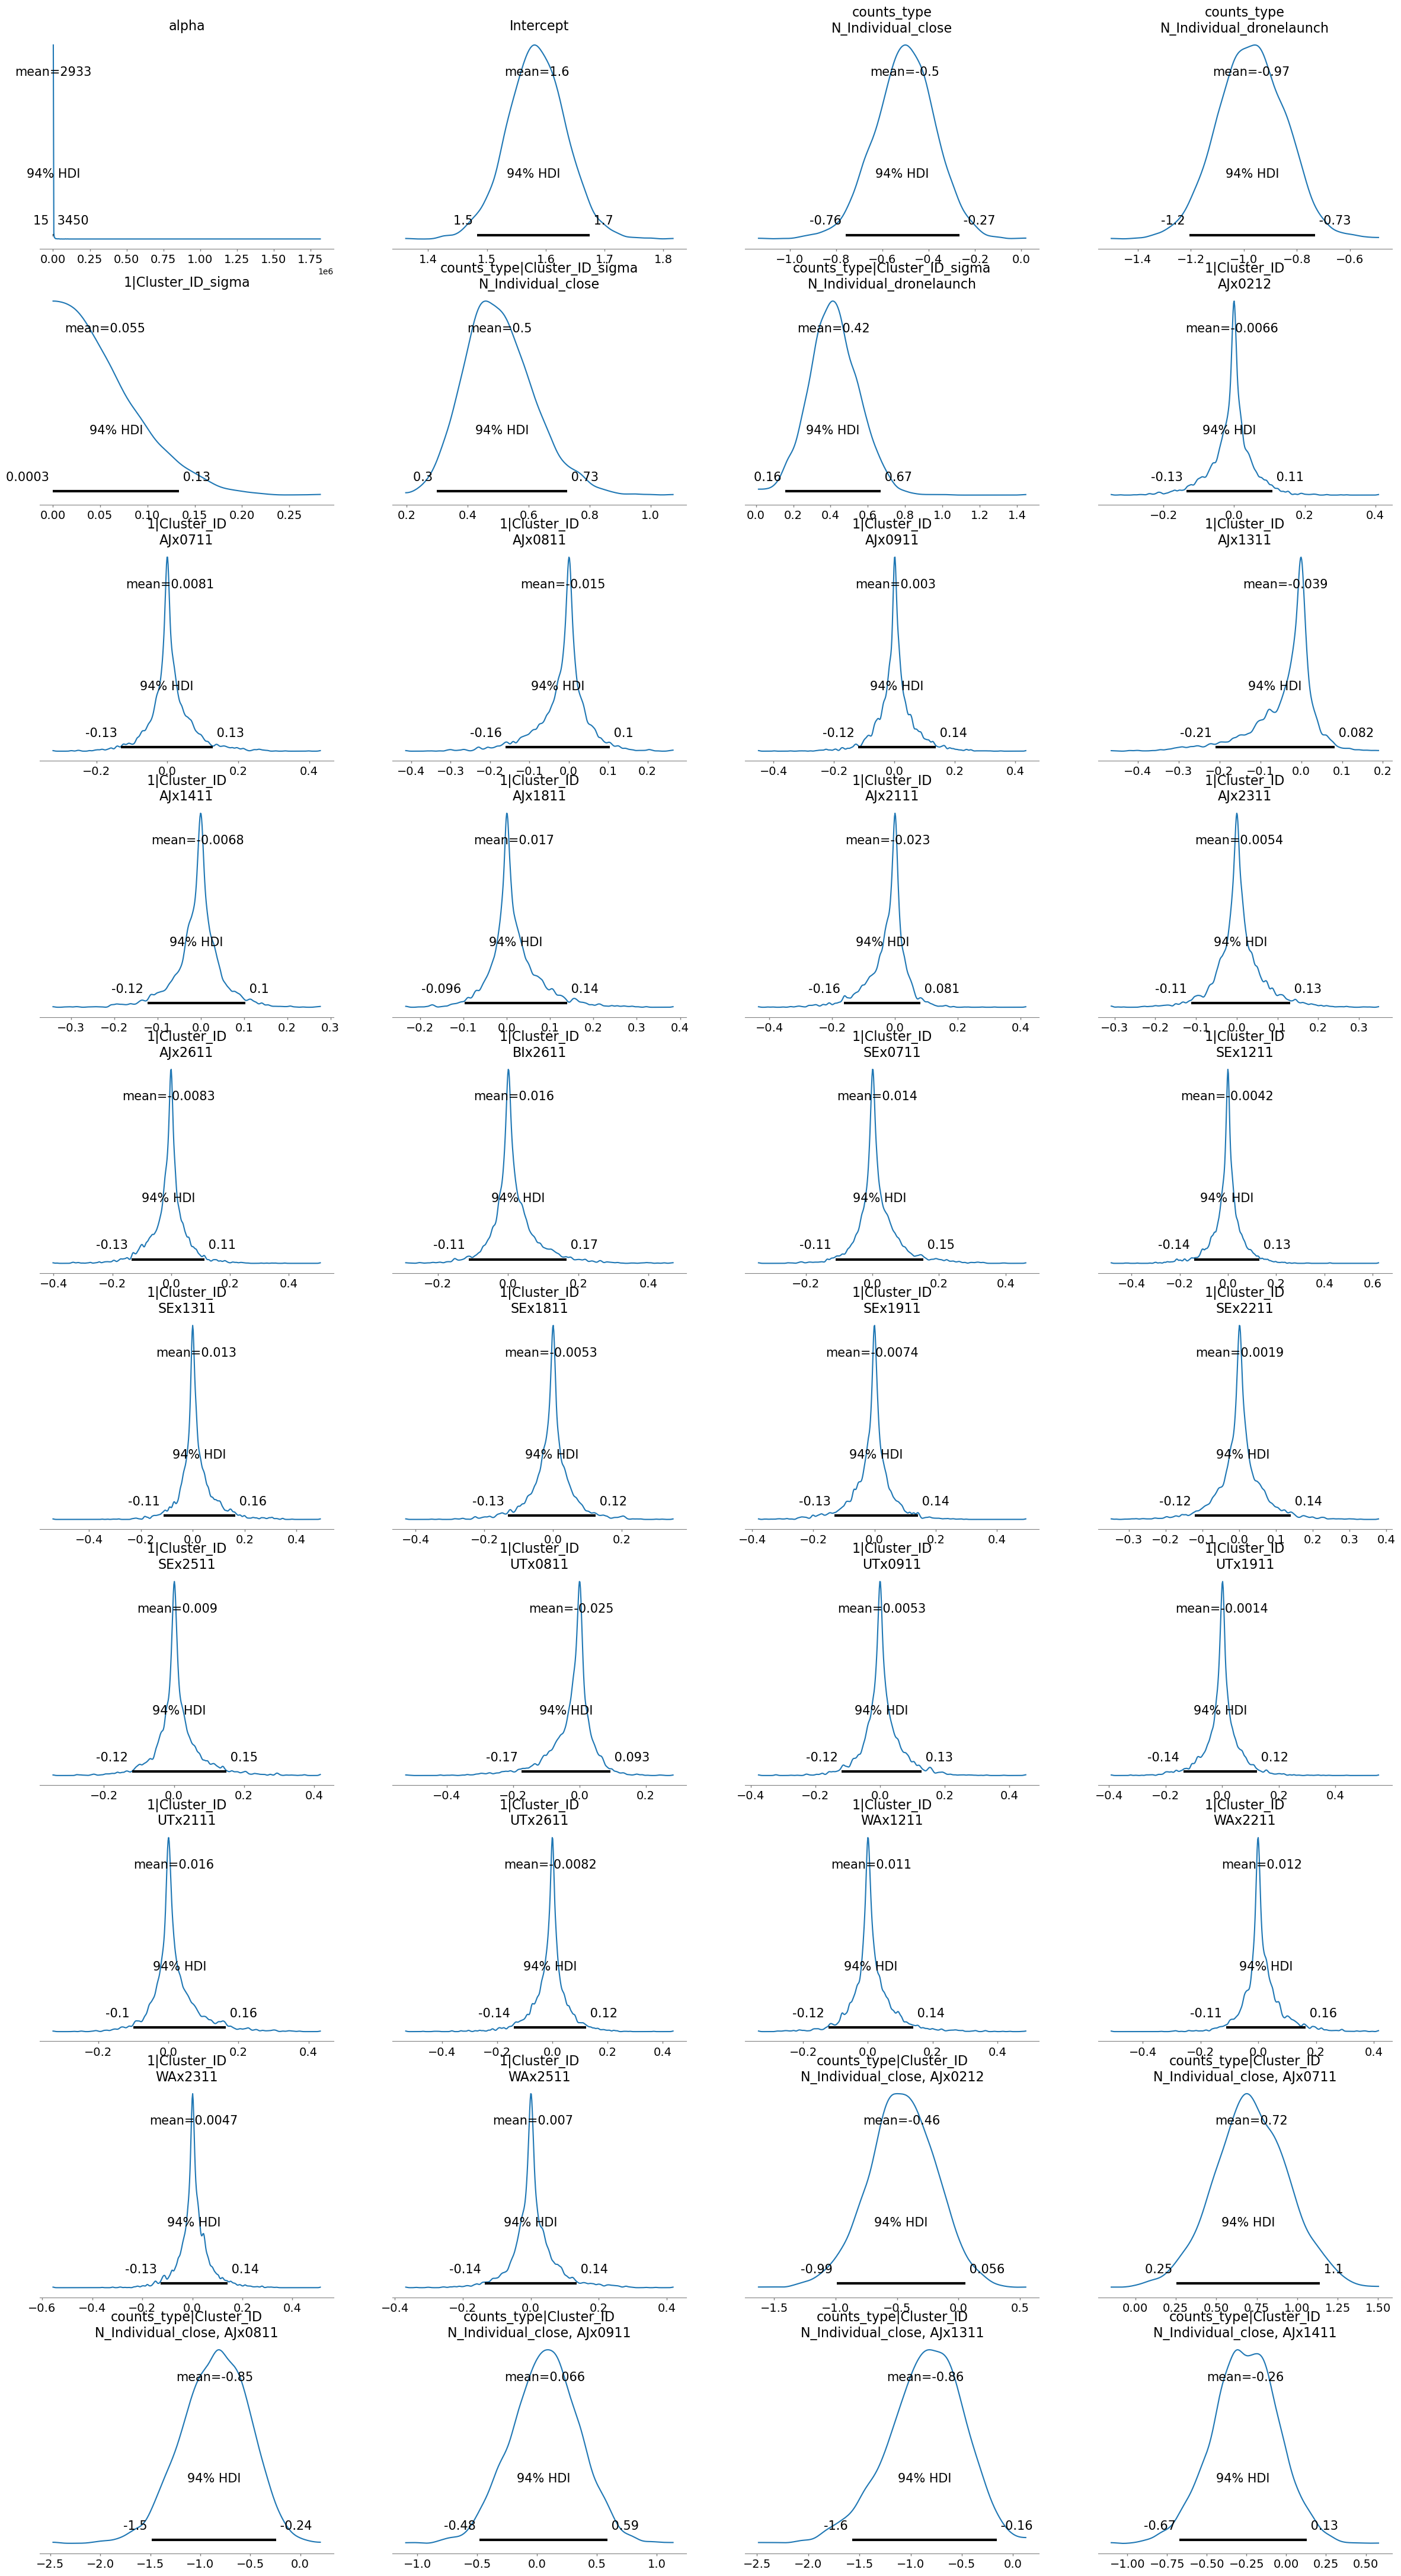

In [9]:
az.plot_posterior(results_individual_nb)

In [10]:
# Print the structure of the inference data
print(results_individual_nb)

# Alternatively, use the repr function for a more detailed view
repr(results_individual_nb)
# Access the observed_data group
observed_data = results_individual_nb.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 3kB
Dimensions:      (__obs__: 207)
Coordinates:
  * __obs__      (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 201 202 203 204 205 206
Data variables:
    total_count  (__obs__) int64 2kB 7 11 11 3 1 10 1 1 9 ... 2 2 3 3 3 1 1 2 2
Attributes:
    created_at:                  2026-02-06T10:44:27.025574+00:00
    arviz_version:               0.22.0
    inference_library:           pymc
    inference_library_version:   5.25.1
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


In [11]:
# Generate posterior predictive samples
posterior_predictive = model_individual_nb.predict(results_individual_nb, kind="pps")

# Add the posterior predictive samples to the inference data
results_individual_nb.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results_individual_nb, data_pairs={"total_count": "total_count"})

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future


ValueError: ['posterior_predictive'] group(s) already exists.

<xarray.Dataset> Size: 7MB
Dimensions:      (chain: 4, draw: 1000, __obs__: 207)
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * __obs__      (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 201 202 203 204 205 206
Data variables:
    total_count  (chain, draw, __obs__) int64 7MB 4 7 8 2 4 8 2 ... 4 1 0 2 1 3
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


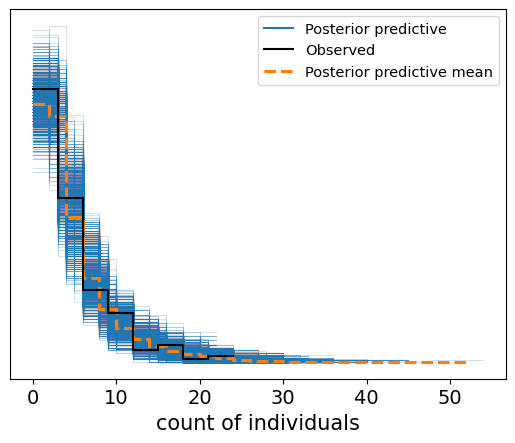

In [12]:
# Check the structure of the posterior_predictive group
print(results_individual_nb.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results_individual_nb, data_pairs={"total_count": "total_count"})
plt.xlabel('count of individuals')
plt.savefig('pp_modelindividuals.png', bbox_inches='tight')

### **Model ADULT FEMALES**

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (88) in plot_posterior, generating only 40 plots


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'counts_type\nN_F_close'}>,
        <Axes: title={'center': 'counts_type\nN_F_dronelaunch'}>],
       [<Axes: title={'center': '1|Cluster_ID_sigma'}>,
        <Axes: title={'center': 'counts_type|Cluster_ID_sigma\nN_F_close'}>,
        <Axes: title={'center': 'counts_type|Cluster_ID_sigma\nN_F_dronelaunch'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0212'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx0711'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0811'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0911'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1311'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx1411'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1811'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2111'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2311'}>],
       [<Axes: title={'center': '

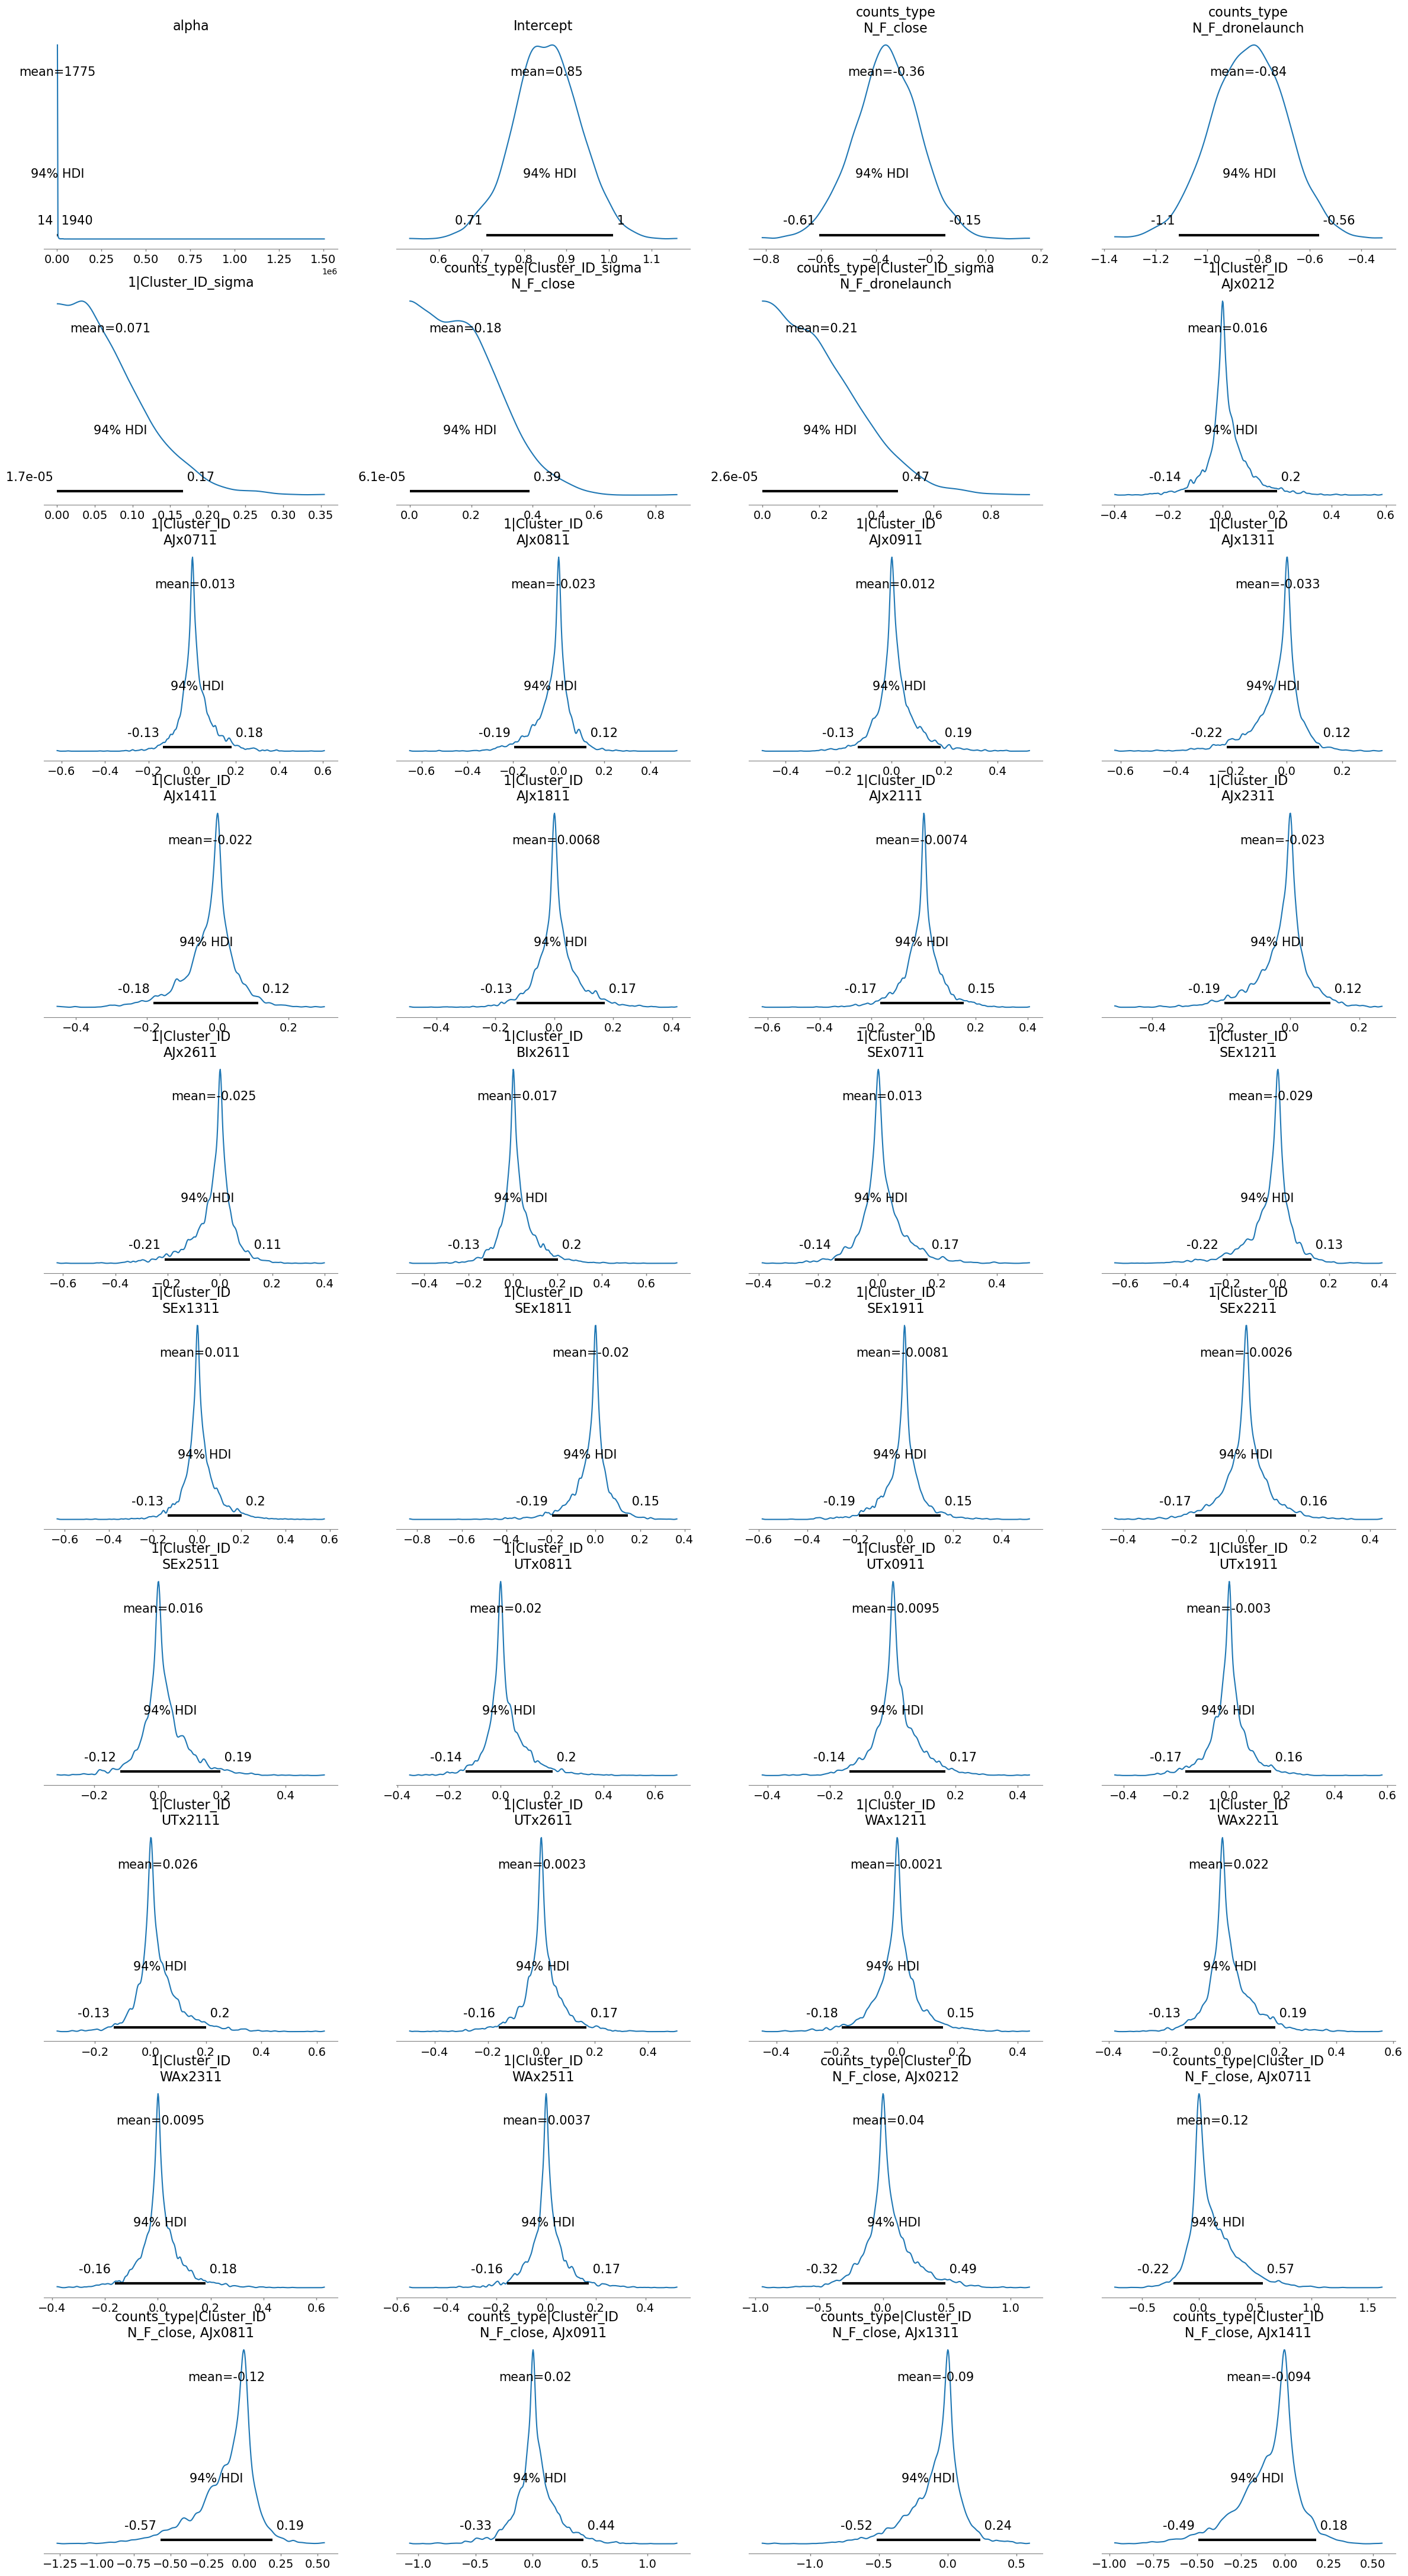

In [16]:
az.plot_posterior(results_F_nb)

In [17]:
# Print the structure of the inference data
print(results_F_nb)

# Alternatively, use the repr function for a more detailed view
repr(results_F_nb)
# Access the observed_data group
observed_data = results_F_nb.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 3kB
Dimensions:      (__obs__: 195)
Coordinates:
  * __obs__      (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 189 190 191 192 193 194
Data variables:
    total_count  (__obs__) int64 2kB 3 2 2 3 1 4 1 1 3 4 ... 1 0 2 2 2 1 1 1 1 1
Attributes:
    created_at:                  2026-02-06T10:46:50.260556+00:00
    arviz_version:               0.22.0
    inference_library:           pymc
    inference_library_version:   5.25.1
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


In [18]:
# Generate posterior predictive samples
posterior_predictive = model_F_nb.predict(results_F_nb, kind="pps")

# Add the posterior predictive samples to the inference data
results_F_nb.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results_F_nb, data_pairs={"total_count": "total_count"})

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future


ValueError: ['posterior_predictive'] group(s) already exists.

<xarray.Dataset> Size: 6MB
Dimensions:      (chain: 4, draw: 1000, __obs__: 195)
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * __obs__      (__obs__) int64 2kB 0 1 2 3 4 5 6 ... 189 190 191 192 193 194
Data variables:
    total_count  (chain, draw, __obs__) int64 6MB 0 0 0 6 3 4 4 ... 2 2 0 0 5 2
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


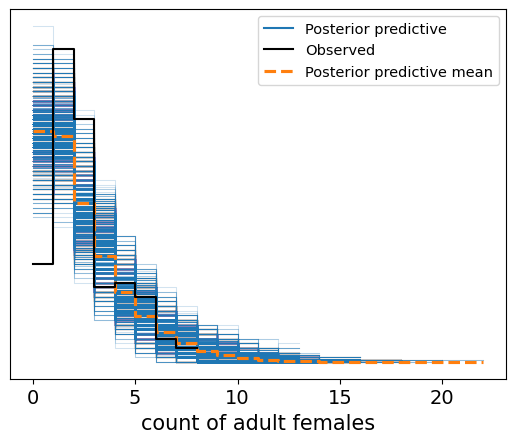

In [20]:
# Check the structure of the posterior_predictive group
print(results_F_nb.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results_F_nb, data_pairs={"total_count": "total_count"})
plt.xlabel('count of adult females')
plt.savefig('pp_modelfemales.png', bbox_inches='tight')

### **Model ADULT MALES**

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (61) in plot_posterior, generating only 40 plots


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'counts_type\nN_M_close'}>,
        <Axes: title={'center': 'counts_type\nN_M_dronelaunch'}>],
       [<Axes: title={'center': '1|Cluster_ID_sigma'}>,
        <Axes: title={'center': 'counts_type|Cluster_ID_sigma\nN_M_close'}>,
        <Axes: title={'center': 'counts_type|Cluster_ID_sigma\nN_M_dronelaunch'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0711'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx1411'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1811'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2111'}>,
        <Axes: title={'center': '1|Cluster_ID\nBIx2611'}>],
       [<Axes: title={'center': '1|Cluster_ID\nSEx0711'}>,
        <Axes: title={'center': '1|Cluster_ID\nSEx1211'}>,
        <Axes: title={'center': '1|Cluster_ID\nSEx1311'}>,
        <Axes: title={'center': '1|Cluster_ID\nSEx1811'}>],
       [<Axes: title={'center': '

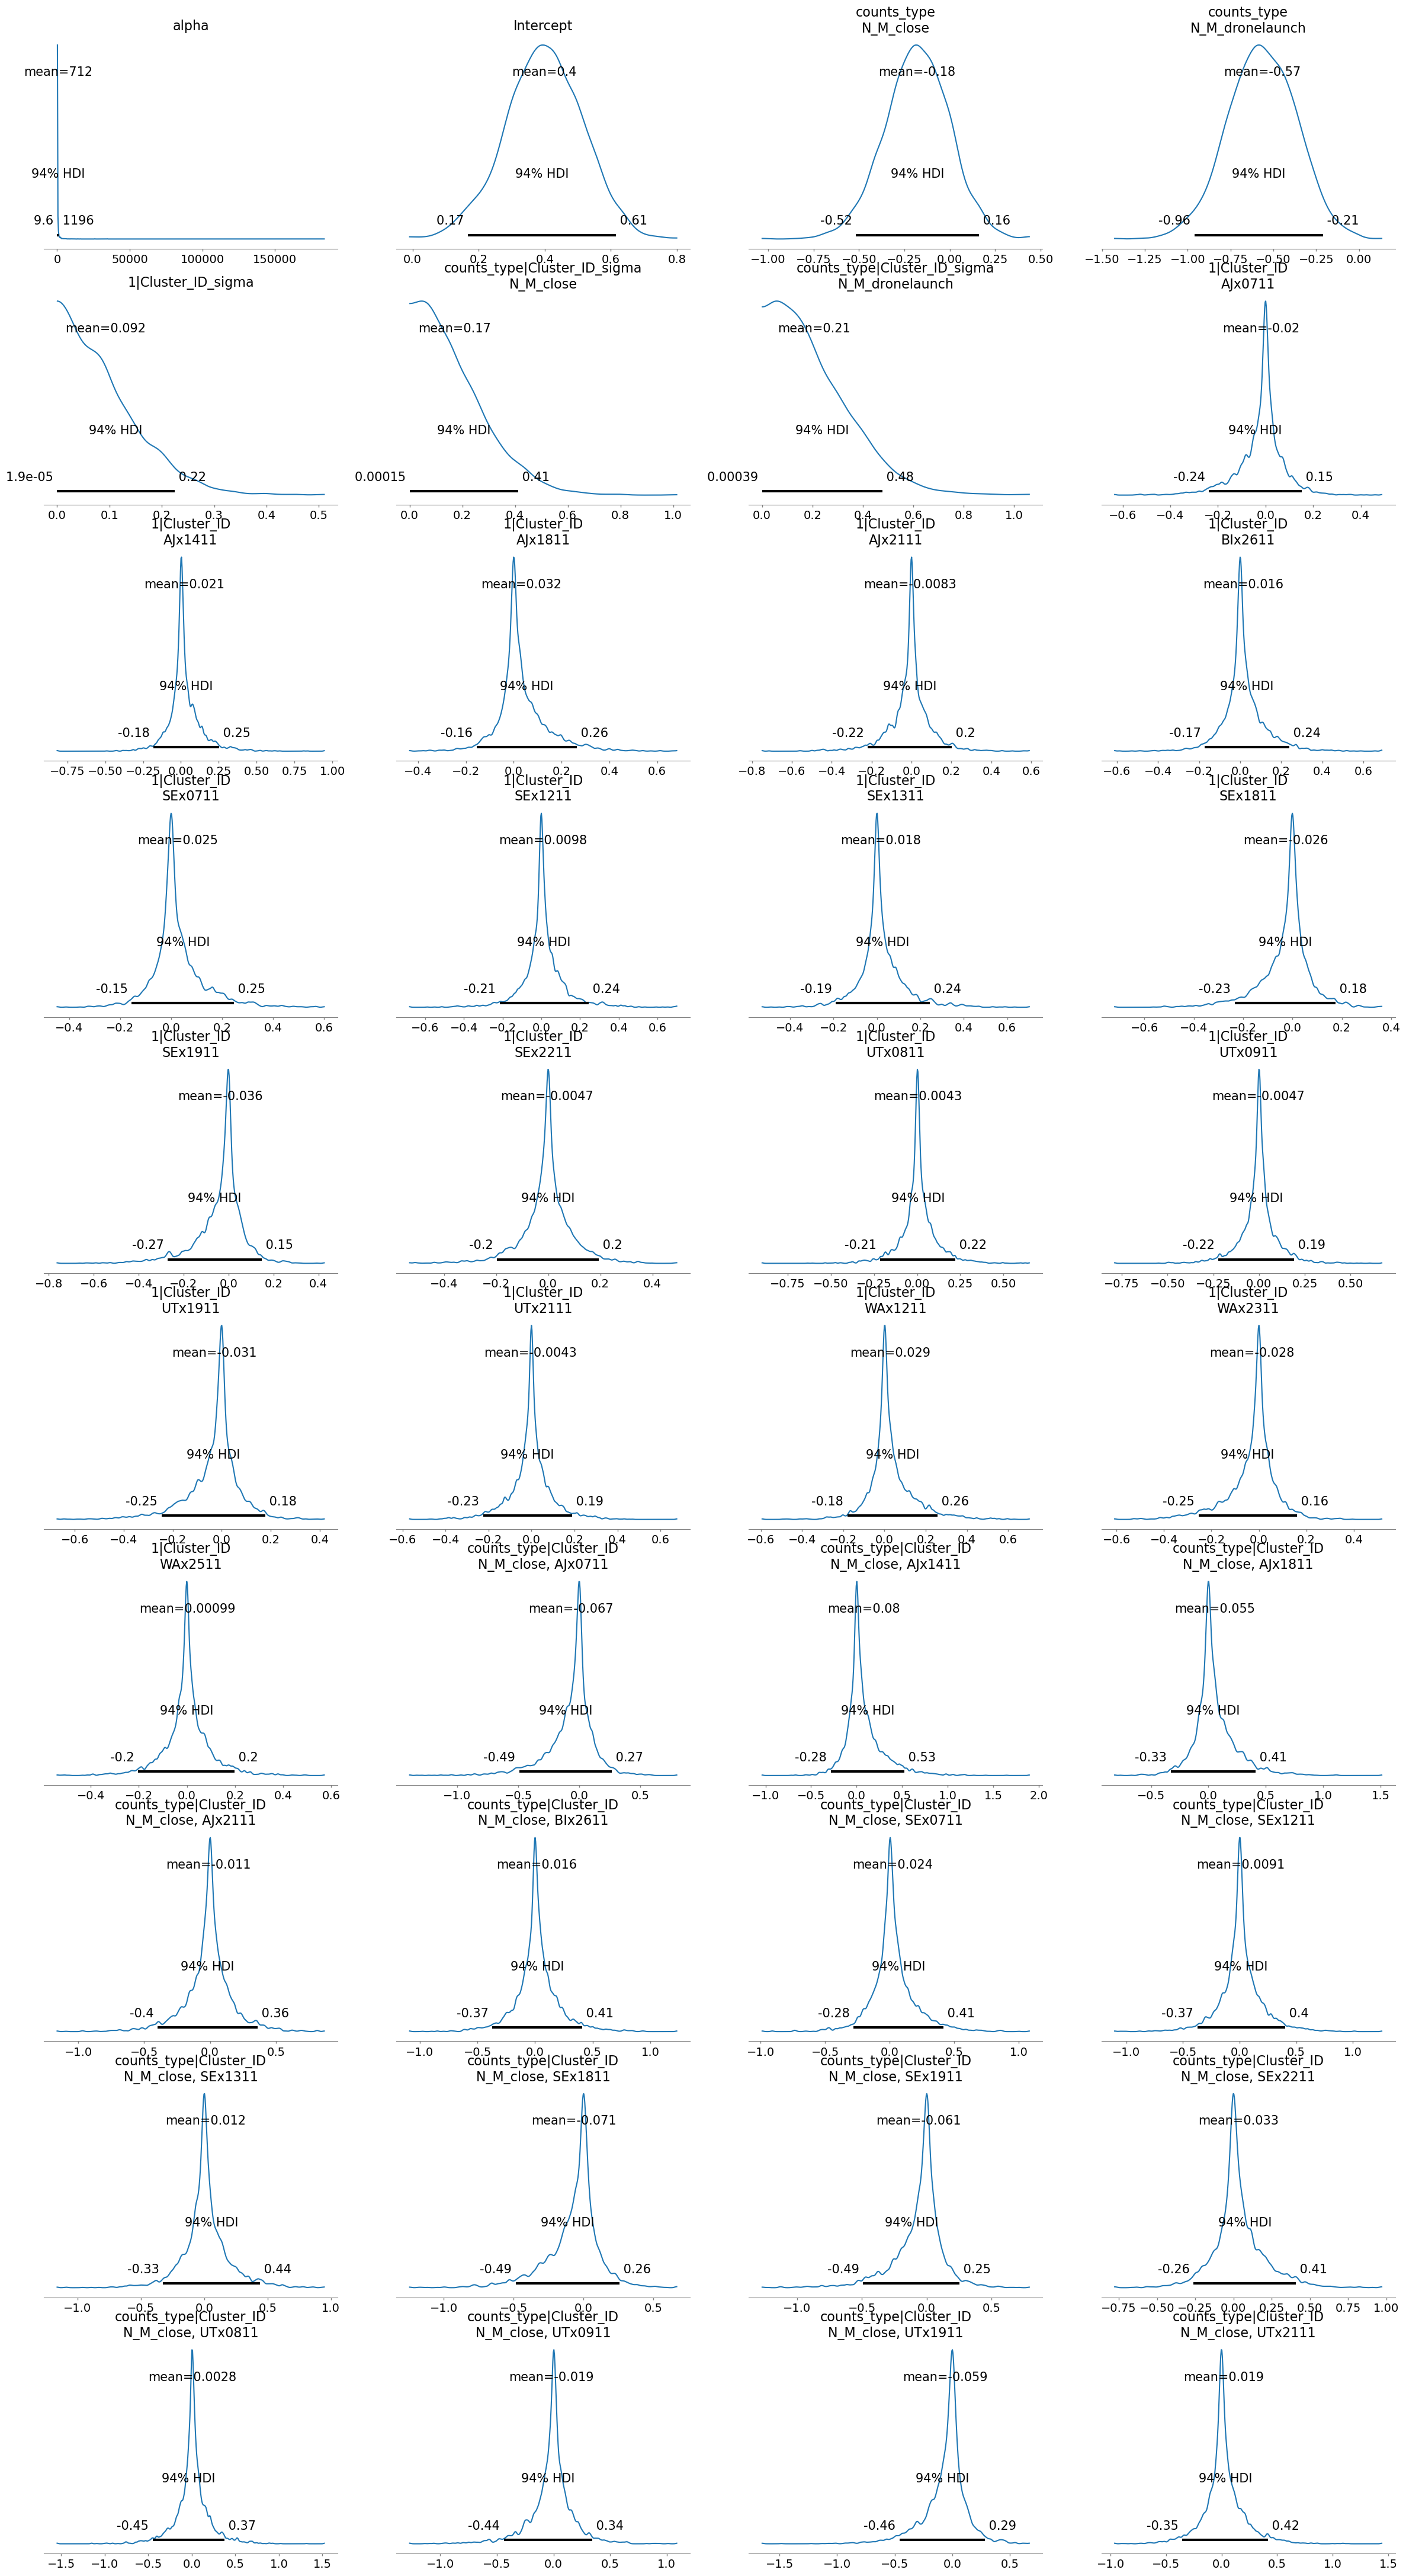

In [21]:
az.plot_posterior(results_M_nb)

In [22]:
# Print the structure of the inference data
print(results_M_nb)

# Alternatively, use the repr function for a more detailed view
repr(results_M_nb)
# Access the observed_data group
observed_data = results_M_nb.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 2kB
Dimensions:      (__obs__: 144)
Coordinates:
  * __obs__      (__obs__) int64 1kB 0 1 2 3 4 5 6 ... 138 139 140 141 142 143
Data variables:
    total_count  (__obs__) int64 1kB 1 1 1 2 2 2 2 2 1 2 ... 2 1 1 2 2 2 1 1 1 1
Attributes:
    created_at:                  2026-02-06T10:46:56.391013+00:00
    arviz_version:               0.22.0
    inference_library:           pymc
    inference_library_version:   5.25.1
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


In [23]:
# Generate posterior predictive samples
posterior_predictive = model_M_nb.predict(results_M_nb, kind="pps")

# Add the posterior predictive samples to the inference data
results_M_nb.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results_M_nb, data_pairs={"total_count": "total_count"})

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future


ValueError: ['posterior_predictive'] group(s) already exists.

<xarray.Dataset> Size: 5MB
Dimensions:      (chain: 4, draw: 1000, __obs__: 144)
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * __obs__      (__obs__) int64 1kB 0 1 2 3 4 5 6 ... 138 139 140 141 142 143
Data variables:
    total_count  (chain, draw, __obs__) int64 5MB 3 1 0 0 0 1 4 ... 1 1 0 0 2 1
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


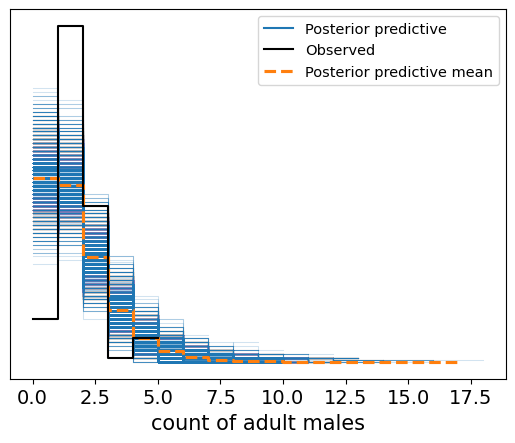

In [24]:
# Check the structure of the posterior_predictive group
print(results_M_nb.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results_M_nb, data_pairs={"total_count": "total_count"})
plt.xlabel('count of adult males')
plt.savefig('pp_modelmales.png', bbox_inches='tight')

### **Model CUBS**

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (46) in plot_posterior, generating only 40 plots


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'counts_type\nN_c_close'}>,
        <Axes: title={'center': 'counts_type\nN_c_dronelaunch'}>],
       [<Axes: title={'center': '1|Cluster_ID_sigma'}>,
        <Axes: title={'center': 'counts_type|Cluster_ID_sigma\nN_c_close'}>,
        <Axes: title={'center': 'counts_type|Cluster_ID_sigma\nN_c_dronelaunch'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0212'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx0711'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0811'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0911'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1311'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx1411'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1811'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2111'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2311'}>],
       [<Axes: title={'center': '

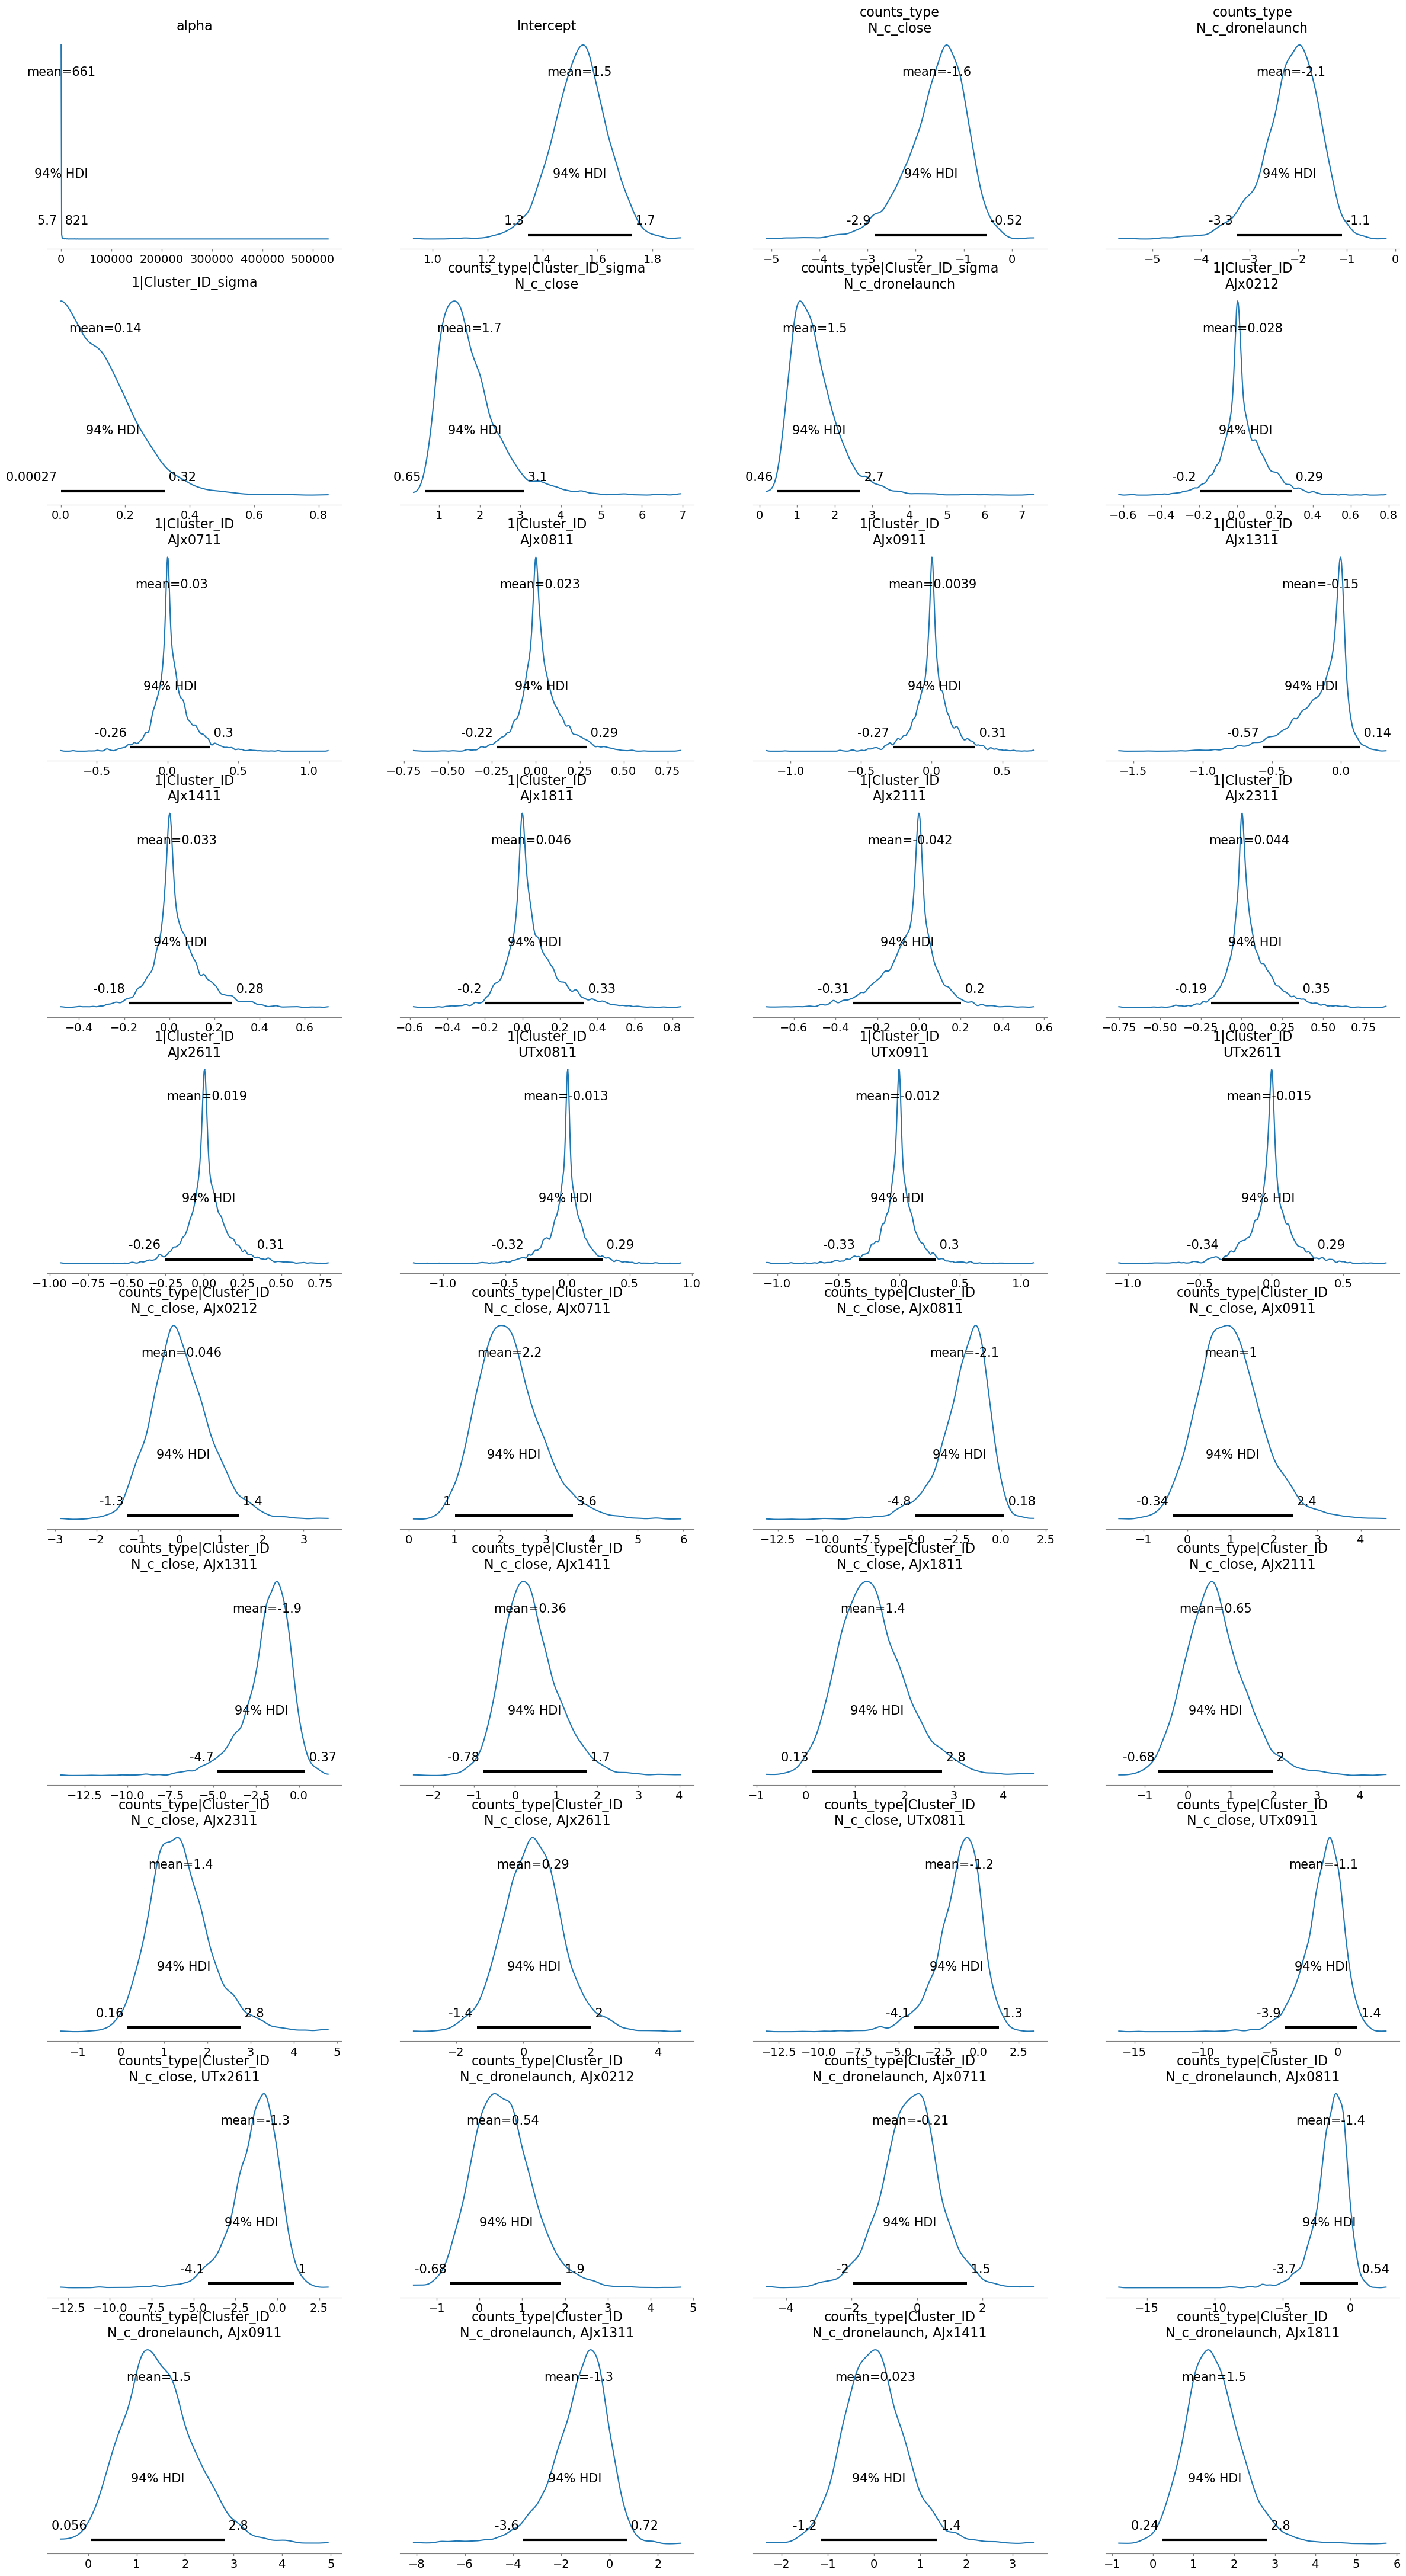

In [25]:
az.plot_posterior(results_c_nb)

In [26]:
# Print the structure of the inference data
print(results_c_nb)

# Alternatively, use the repr function for a more detailed view
repr(results_c_nb)
# Access the observed_data group
observed_data = results_c_nb.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 1kB
Dimensions:      (__obs__: 87)
Coordinates:
  * __obs__      (__obs__) int64 696B 0 1 2 3 4 5 6 7 ... 80 81 82 83 84 85 86
Data variables:
    total_count  (__obs__) int64 696B 3 8 8 0 0 6 0 0 4 ... 3 14 14 4 1 1 1 3 2
Attributes:
    created_at:                  2026-02-06T10:47:06.534078+00:00
    arviz_version:               0.22.0
    inference_library:           pymc
    inference_library_version:   5.25.1
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


In [27]:
# Generate posterior predictive samples
posterior_predictive = model_c_nb.predict(results_c_nb, kind="pps")

# Add the posterior predictive samples to the inference data
results_c_nb.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results_c_nb, data_pairs={"total_count": "total_count"})

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future


ValueError: ['posterior_predictive'] group(s) already exists.

<xarray.Dataset> Size: 3MB
Dimensions:      (chain: 4, draw: 1000, __obs__: 87)
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * __obs__      (__obs__) int64 696B 0 1 2 3 4 5 6 7 ... 80 81 82 83 84 85 86
Data variables:
    total_count  (chain, draw, __obs__) int64 3MB 7 2 7 0 1 3 0 ... 2 0 1 3 3 1
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


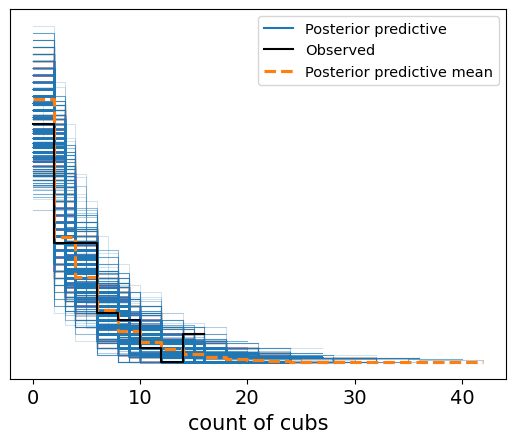

In [28]:
# Check the structure of the posterior_predictive group
print(results_c_nb.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results_c_nb, data_pairs={"total_count": "total_count"})
plt.xlabel('count of cubs')
plt.savefig('pp_modelcubs.png', bbox_inches='tight')

### **Model 4**

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Time_Sin'}>,
        <Axes: title={'center': 'Time_Cos'}>],
       [<Axes: title={'center': '1|Cluster_ID_sigma'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0212'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0711'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0811'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx0911'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1311'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1411'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1811'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx2111'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2311'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2611'}>,
        <Axes: title={'center': '1|Cluster_ID\nBIx2611'}>],
       [<Axes: title={'center': '1|Cluster_ID\nSEx0711'}>,
        <Axes: title={'center': '1|Cluster_ID\nSEx

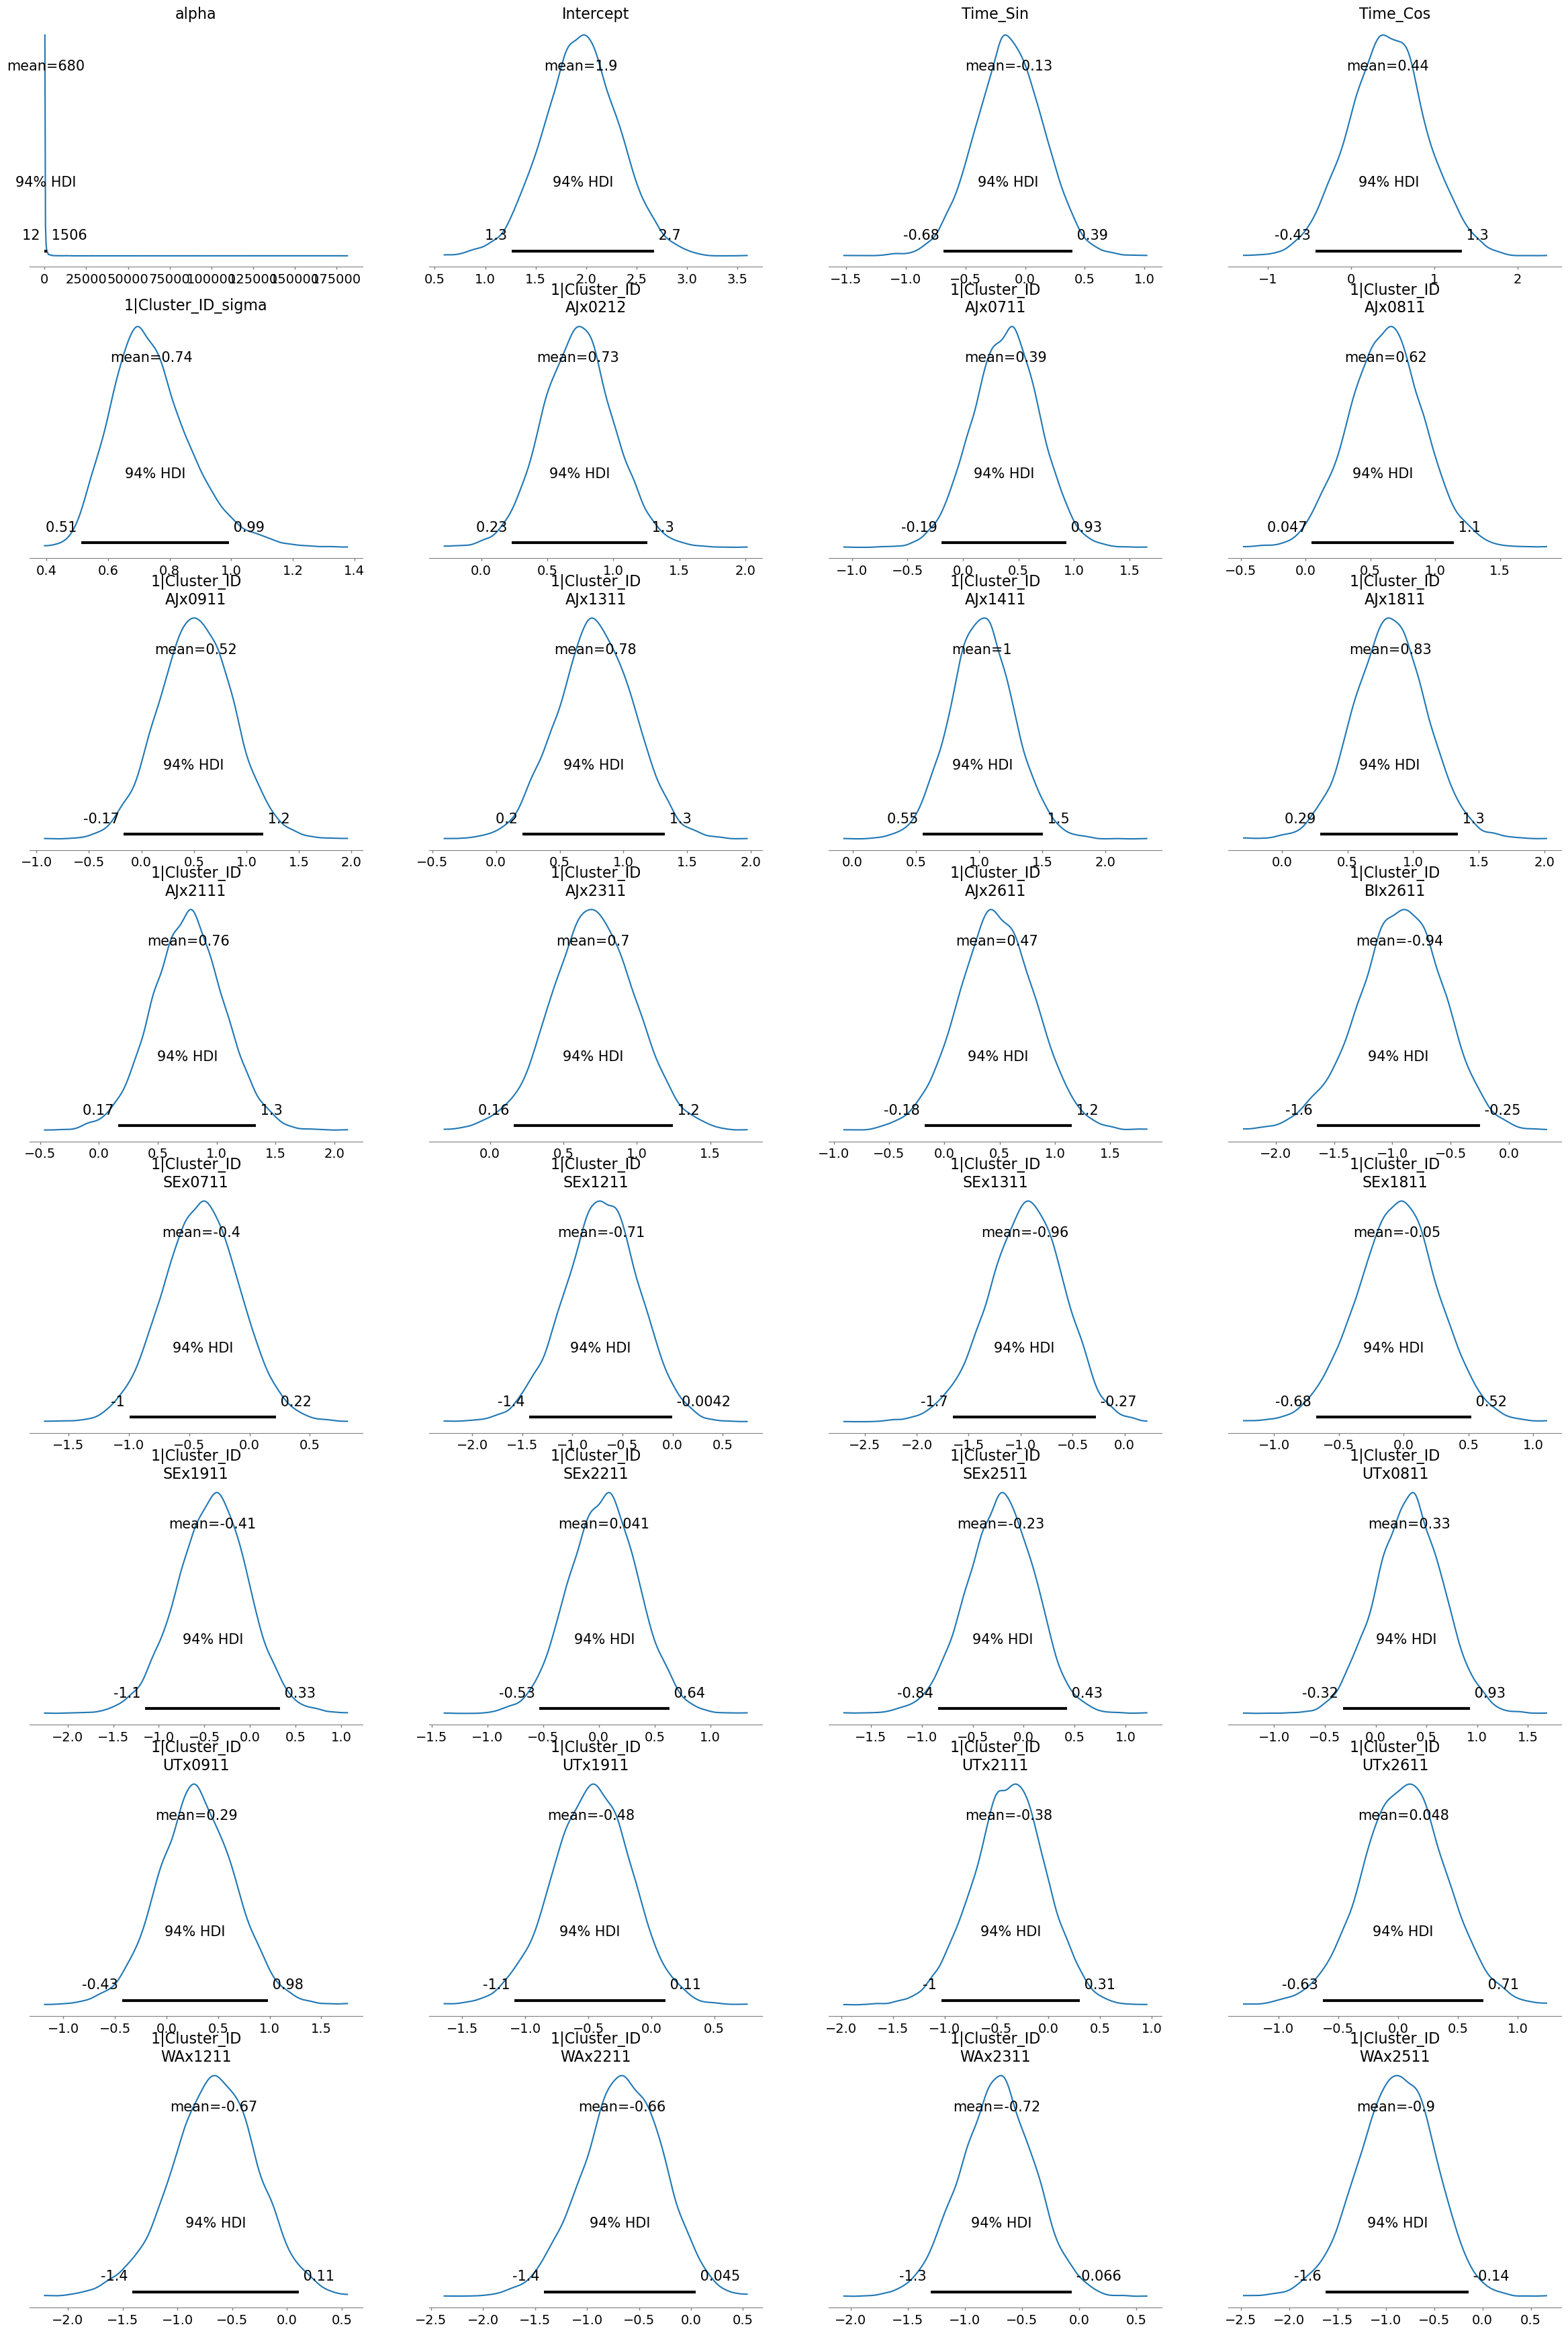

In [85]:
az.plot_posterior(results_individual3)

In [86]:
# Print the structure of the inference data
print(results_individual3)

# Alternatively, use the repr function for a more detailed view
repr(results_individual3)
# Access the observed_data group
observed_data = results_individual3.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 1kB
Dimensions:      (__obs__: 69)
Coordinates:
  * __obs__      (__obs__) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
Data variables:
    total_count  (__obs__) int64 552B 6 6 9 15 15 15 11 11 ... 2 3 3 3 1 1 2 2
Attributes:
    created_at:                  2026-01-12T14:50:03.415385+00:00
    arviz_version:               0.22.0
    inference_library:           pymc
    inference_library_version:   5.25.1
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


In [88]:
# Generate posterior predictive samples
posterior_predictive = model_individual3.predict(results_individual3, kind="pps")

# Add the posterior predictive samples to the inference data
results_individual3.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results_individual3, data_pairs={"total_count": "total_count"})

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future


ValueError: ['posterior_predictive'] group(s) already exists.

<xarray.Dataset> Size: 4MB
Dimensions:      (chain: 4, draw: 2000, __obs__: 69)
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 16kB 0 1 2 3 4 5 ... 1994 1995 1996 1997 1998 1999
  * __obs__      (__obs__) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
Data variables:
    total_count  (chain, draw, __obs__) int64 4MB 6 4 5 6 5 28 9 ... 2 0 1 2 3 1
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


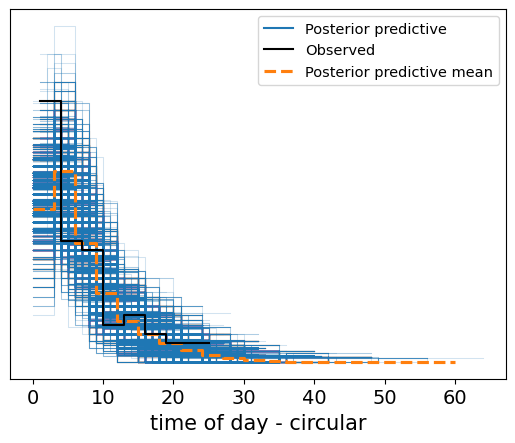

In [89]:
# Check the structure of the posterior_predictive group
print(results_individual3.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results_individual3, data_pairs={"total_count": "total_count"})
plt.xlabel('time of day - circular')
plt.savefig('pp_modeltimecircular.png', bbox_inches='tight')

### **Model 3**

array([[<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Time_Category\nMid morning'}>,
        <Axes: title={'center': 'Time_Category\nLate morning'}>],
       [<Axes: title={'center': 'Time_Category\nMid afternoon'}>,
        <Axes: title={'center': 'Time_Category\nLate afternoon'}>,
        <Axes: title={'center': '1|Cluster_ID_sigma'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx0212'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0711'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0811'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx0911'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1311'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1411'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx1811'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2111'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2311'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx2611'}>,
        <Axes: title={'center': '1|Clust

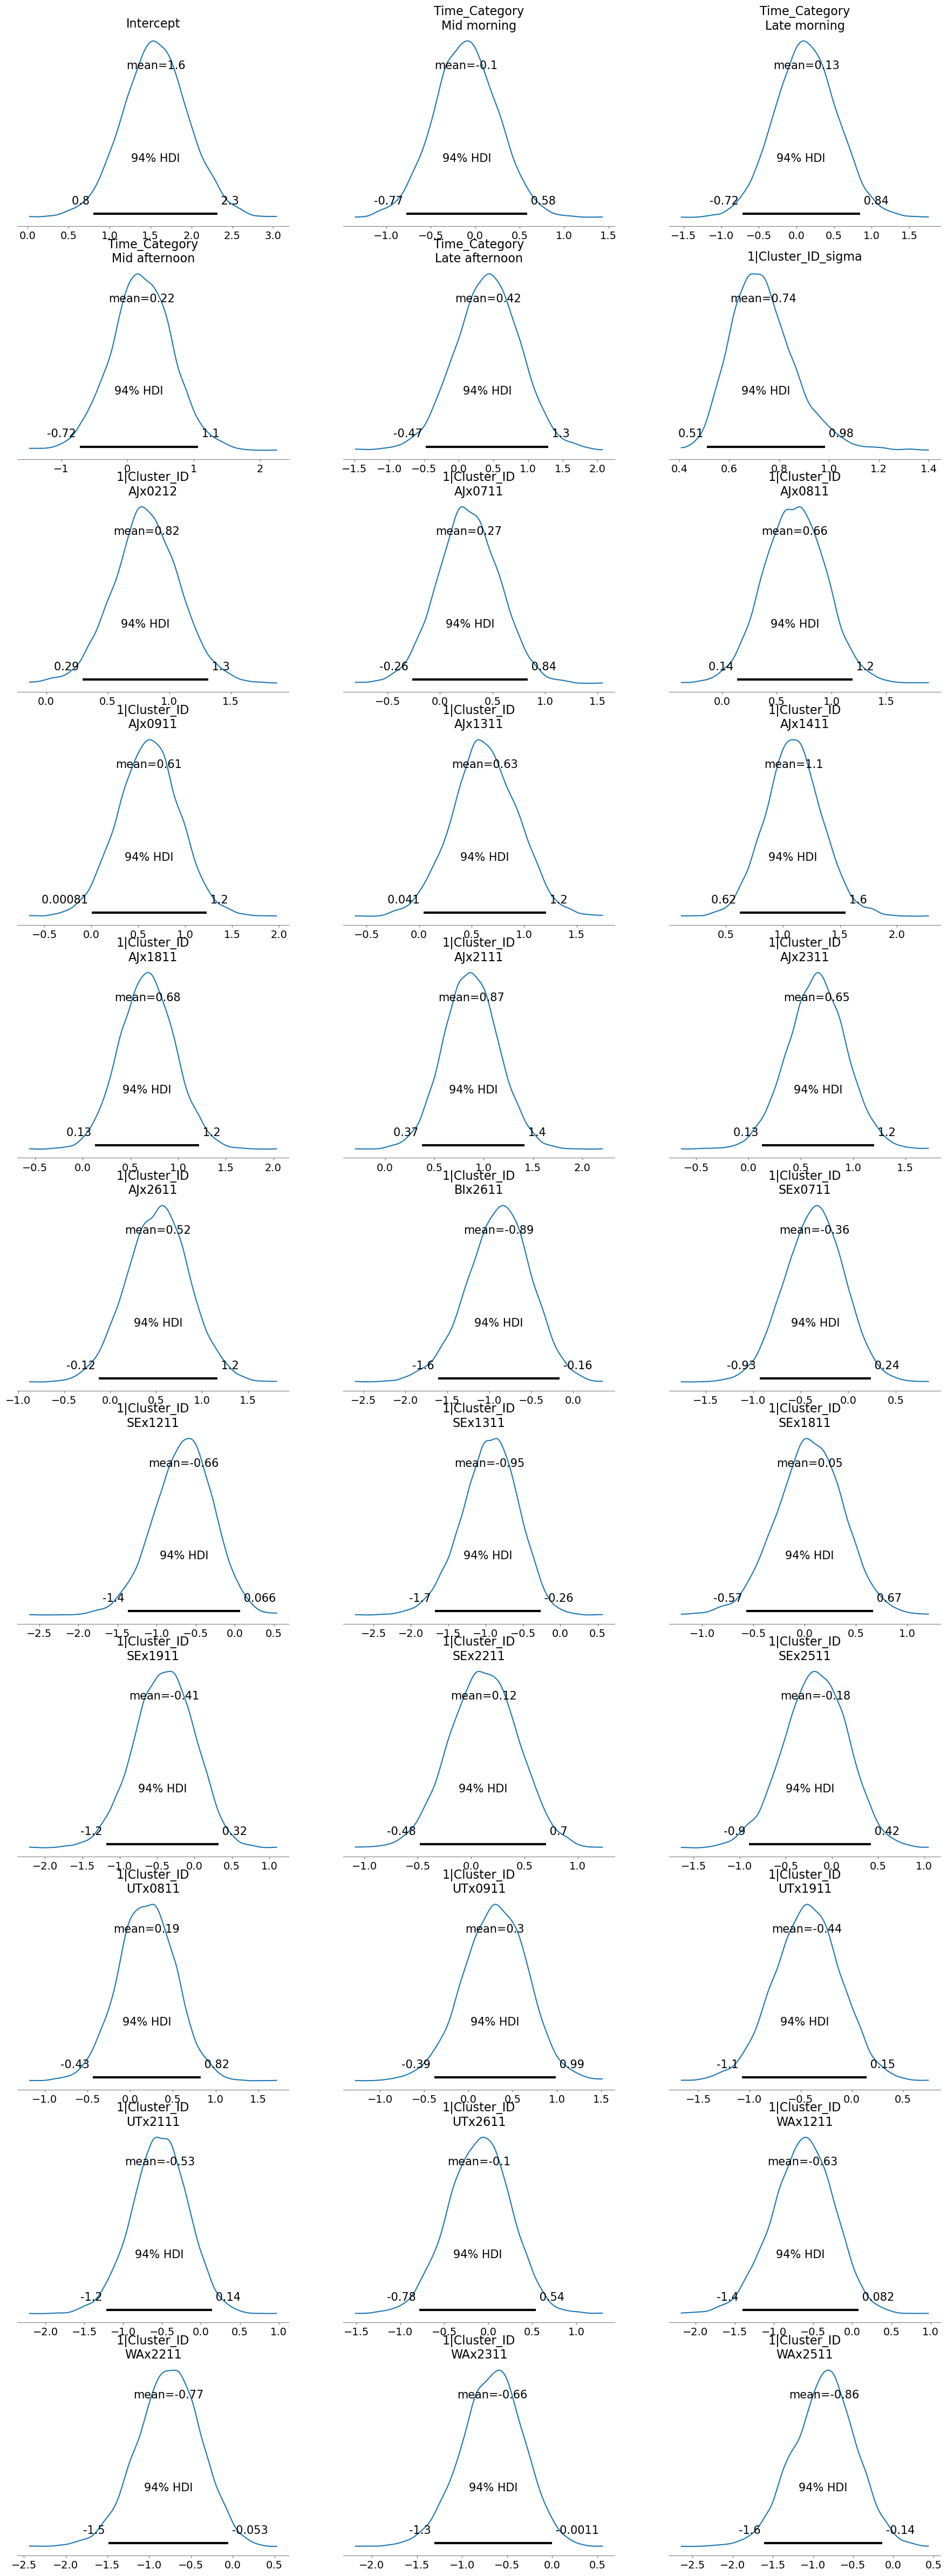

In [90]:
az.plot_posterior(results_individual5)

In [91]:
# Print the structure of the inference data
print(results_individual5)

# Alternatively, use the repr function for a more detailed view
repr(results_individual5)
# Access the observed_data group
observed_data = results_individual5.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 1kB
Dimensions:      (__obs__: 69)
Coordinates:
  * __obs__      (__obs__) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
Data variables:
    total_count  (__obs__) int64 552B 6 6 9 15 15 15 11 11 ... 2 3 3 3 1 1 2 2
Attributes:
    created_at:                  2026-01-12T14:49:46.021656+00:00
    arviz_version:               0.22.0
    inference_library:           pymc
    inference_library_version:   5.25.1
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


In [93]:
# Generate posterior predictive samples
posterior_predictive = model_individual5.predict(results_individual5, kind="pps")

# Add the posterior predictive samples to the inference data
results_individual5.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results_individual5, data_pairs={"total_count": "total_count"})

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future


ValueError: ['posterior_predictive'] group(s) already exists.

<xarray.Dataset> Size: 4MB
Dimensions:      (chain: 4, draw: 2000, __obs__: 69)
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 16kB 0 1 2 3 4 5 ... 1994 1995 1996 1997 1998 1999
  * __obs__      (__obs__) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
Data variables:
    total_count  (chain, draw, __obs__) int64 4MB 3 4 4 16 19 23 ... 6 6 1 1 1 1
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


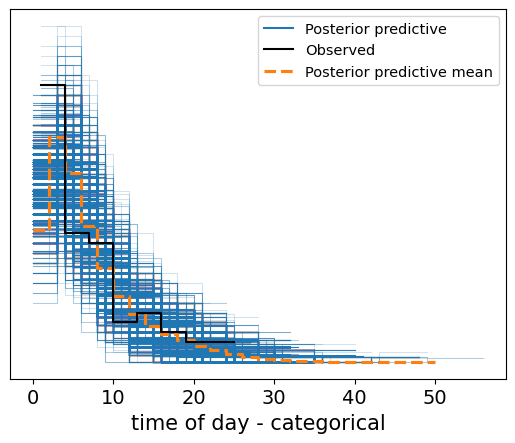

In [94]:
# Check the structure of the posterior_predictive group
print(results_individual5.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results_individual5, data_pairs={"total_count": "total_count"})
plt.xlabel('time of day - categorical')
plt.savefig('pp_modeltimecategorical.png', bbox_inches='tight')

### **Model 1**

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'vegetation\nAcacia drepanolobium'}>],
       [<Axes: title={'center': 'vegetation\nGrassland'}>,
        <Axes: title={'center': 'vegetation\nMixed bushland'}>,
        <Axes: title={'center': '1|Cluster_ID_sigma'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx0212'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0711'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx0811'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx0911'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1311'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx1411'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx1811'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2111'}>,
        <Axes: title={'center': '1|Cluster_ID\nAJx2311'}>],
       [<Axes: title={'center': '1|Cluster_ID\nAJx2611'}>,
        <Axes: title={'center': '1|Cluster_ID\nBIx2611'}>,
       

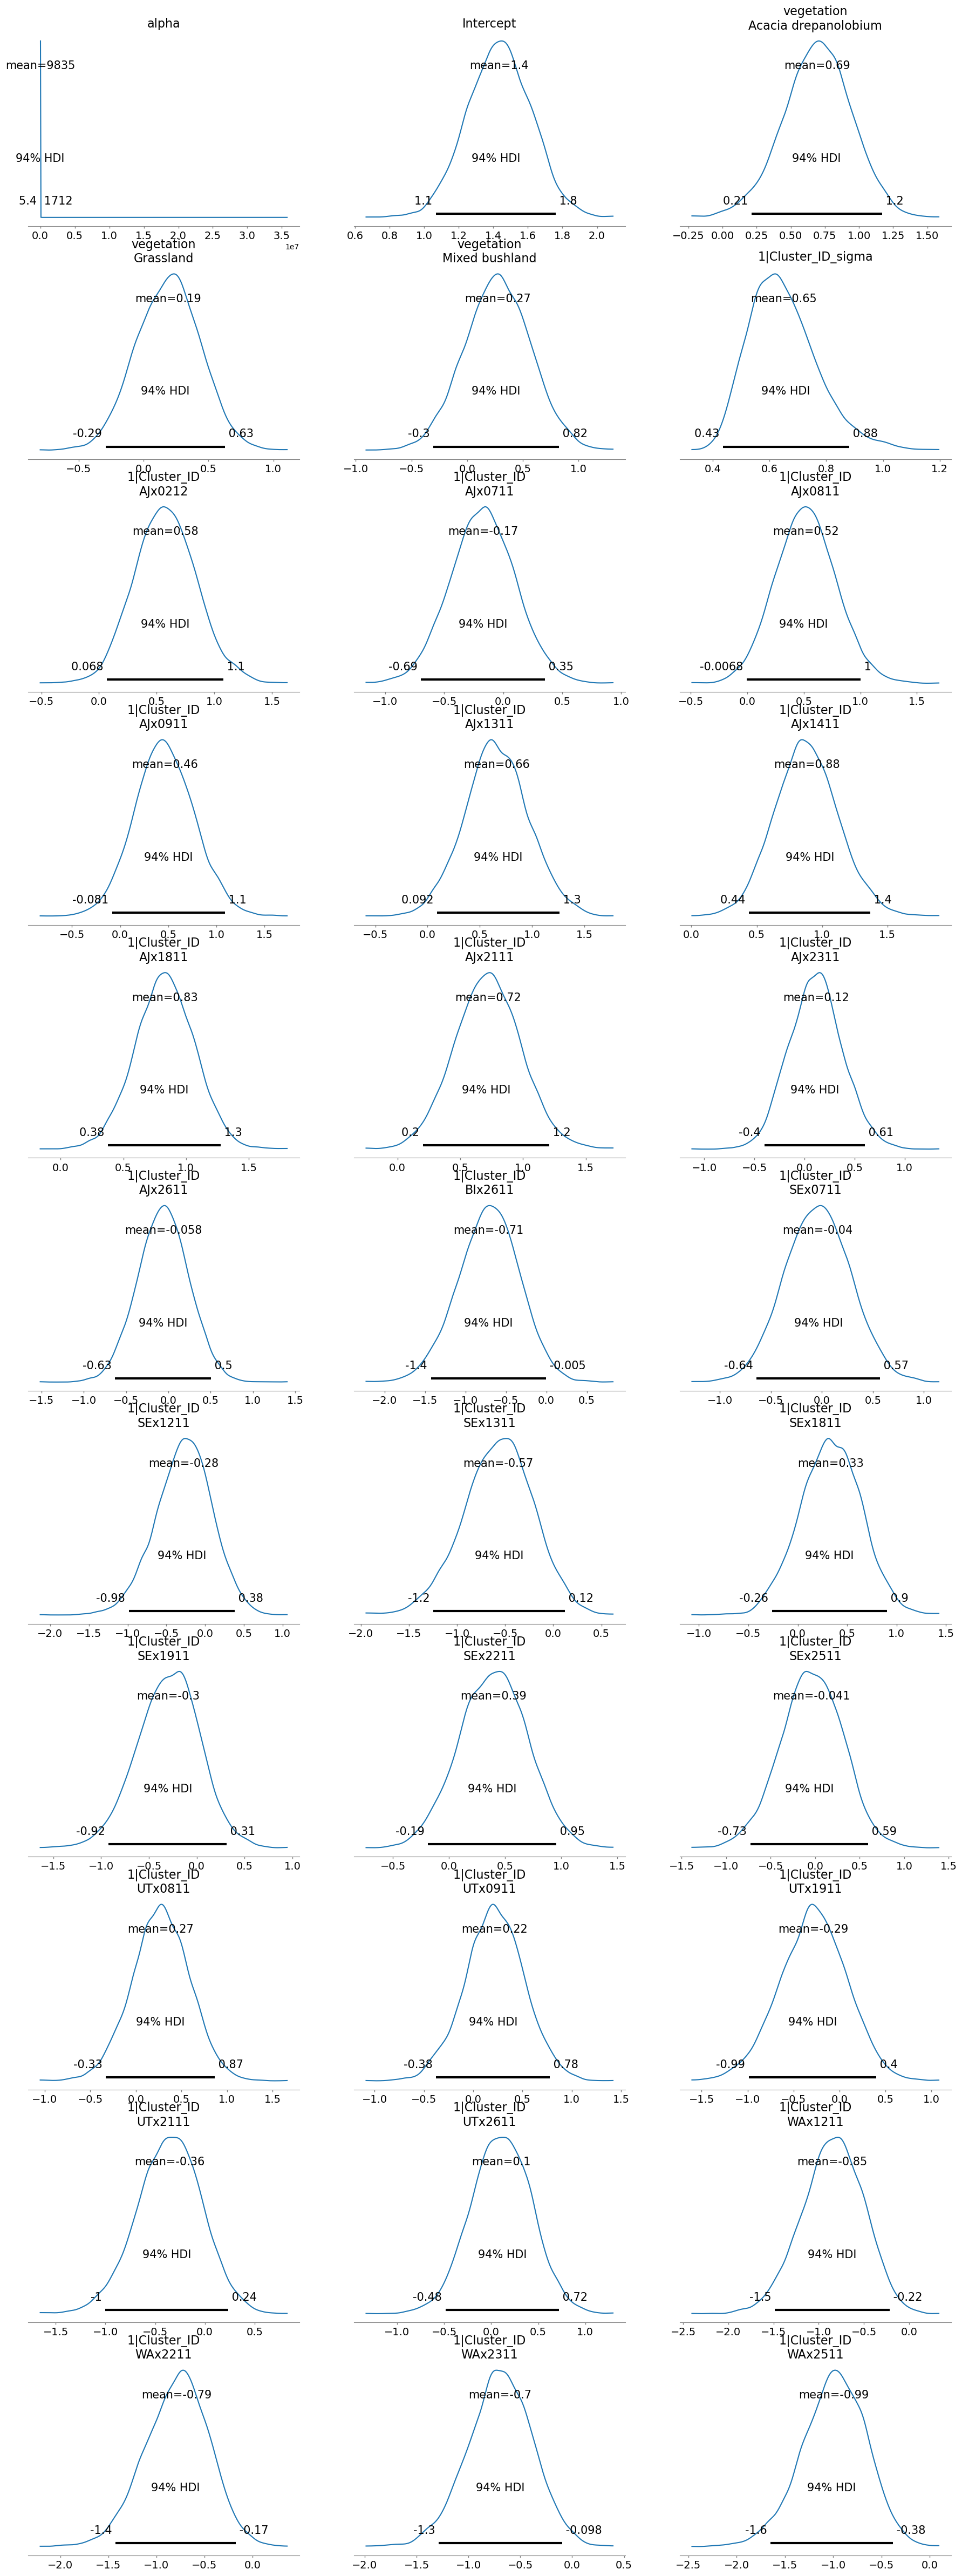

In [95]:
az.plot_posterior(results_individual9)

In [96]:
# Print the structure of the inference data
print(results_individual9)

# Alternatively, use the repr function for a more detailed view
repr(results_individual9)
# Access the observed_data group
observed_data = results_individual9.observed_data

# Print the keys in the observed_data group
print(observed_data)

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
<xarray.Dataset> Size: 1kB
Dimensions:      (__obs__: 69)
Coordinates:
  * __obs__      (__obs__) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
Data variables:
    total_count  (__obs__) int64 552B 6 6 9 15 15 15 11 11 ... 2 3 3 3 1 1 2 2
Attributes:
    created_at:                  2026-01-12T14:48:51.935675+00:00
    arviz_version:               0.22.0
    inference_library:           pymc
    inference_library_version:   5.25.1
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


In [97]:
# Generate posterior predictive samples
posterior_predictive = model_individual9.predict(results_individual9, kind="pps")

# Add the posterior predictive samples to the inference data
results_individual9.add_groups(posterior_predictive=posterior_predictive)

# Now plot the posterior predictive checks
az.plot_ppc(results_individual9, data_pairs={"total_count": "total_count"})

/opt/miniconda3/envs/lion_models/lib/python3.10/site-packages/bambi/models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future


ValueError: ['posterior_predictive'] group(s) already exists.

<xarray.Dataset> Size: 4MB
Dimensions:      (chain: 4, draw: 2000, __obs__: 69)
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 16kB 0 1 2 3 4 5 ... 1994 1995 1996 1997 1998 1999
  * __obs__      (__obs__) int64 552B 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68
Data variables:
    total_count  (chain, draw, __obs__) int64 4MB 4 7 7 18 15 14 ... 1 3 3 1 2 1
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0


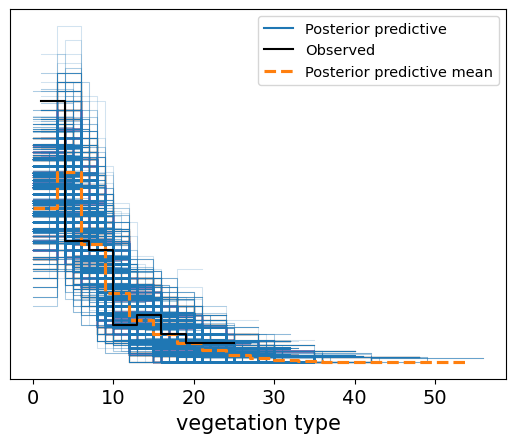

In [98]:
# Check the structure of the posterior_predictive group
print(results_individual9.posterior_predictive)

# Plot posterior predictive checks
az.plot_ppc(results_individual9, data_pairs={"total_count": "total_count"})
plt.xlabel('vegetation type')
plt.savefig('pp_modelvegetation.png', bbox_inches='tight')